# DBTS Train-Only Diagnostic — Full Architecture (In-Sample Sanity Check)

**Goal:** Can the system learn *anything* on data it has already seen?

**Pipeline (train set only):**
1. `build_panel` — regressors (shadow + return) for ALL candidates, walk-forward OOS features
2. `GlobalSignalClassifier.fit` — trained on 100% of train, no validation split, balanced class weights
3. DBTS daily scoring — Thompson Sampling + |residual_z| + |predicted_return| + ADF
4. `PositionManager` — rules-based ENTER / HOLD / EXIT / FLIP per sector
5. Metrics + plots — Sharpe, Win Rate, Drawdown, Equity Curve

**No OOS. No tuning. No validation. Pure memorization check.**


In [8]:
# Cell 1 — TRAIN-ONLY safety switch
TRAIN_ONLY_MODE = True
ALLOW_ANY_NON_TRAIN_DATA = False

assert TRAIN_ONLY_MODE is True
assert ALLOW_ANY_NON_TRAIN_DATA is False

print("TRAIN-ONLY MODE ACTIVE")
print("TRAIN used for fitting: YES")
print("TRAIN used for DBTS diagnostics/evaluation: YES")
print("Any non-train data used: NO")


TRAIN-ONLY MODE ACTIVE
TRAIN used for fitting: YES
TRAIN used for DBTS diagnostics/evaluation: YES
Any non-train data used: NO


In [9]:
# Cell 2 — imports and project path setup
import os
import sys
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore")
%matplotlib inline

# Adjust this if your project lives elsewhere.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strategy").exists():
    candidate = Path(r"C:\algo-trading-project")
    if candidate.exists():
        PROJECT_ROOT = candidate

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")


Project root: c:\algo-trading-project


In [10]:
# Cell 3 — project imports
from config import SECTORS
from strategy.strategy_config import StrategyConfig
from strategy.pipeline import StrategyPipeline
from strategy.splits import chrono_split, walk_forward_folds
from strategy.predictor_selector import PredictorSelector
from strategy.regressors import DynamicShadowPriceModel, DynamicReturnModel
from strategy.residual_features import ResidualFeatureBuilder
from strategy.technical_features import TechnicalRuleFeatureBuilder
from strategy.bandit_target_selector import BanditTargetSelector
from strategy.classifier import GlobalSignalClassifier, make_labels

print("Project imports loaded.")


Project imports loaded.


In [11]:
# Cell 4 — helpers

def safe_price(prices, ticker, date):
    try:
        v = float(prices.at[date, ticker])
        return v if math.isfinite(v) and v > 0 else float("nan")
    except Exception:
        return float("nan")


def make_actual_label(price_series, cfg):
    return make_labels(price_series, cfg)


def signal_name(x):
    return {-1: "short", 0: "flat", 1: "long"}.get(int(x), str(x)) if pd.notna(x) else "nan"


def max_drawdown(equity):
    if equity.empty:
        return float("nan")
    peak = equity.cummax()
    return float((equity / peak - 1.0).min())


def pm_portfolio_metrics(pm_df, periods_per_year=252):
    """
    Portfolio metrics from PositionManager output.
    pm_df has one row per (date, sector/target) with columns:
      net_pnl, position, is_entry, is_exit, action, signal, date, sector, target
    Sectors trade in parallel → average net_pnl across active sectors per day,
    then compound.
    """
    if pm_df.empty:
        return pd.Series(dtype=float)

    # daily portfolio return = average net_pnl across all sectors that day
    daily_ret = pm_df.groupby("date")["net_pnl"].mean().sort_index()
    if daily_ret.empty:
        return pd.Series(dtype=float)

    equity = (1.0 + daily_ret).cumprod()
    cum = float(equity.iloc[-1] - 1.0)
    n = len(daily_ret)
    ann_ret = float((1.0 + cum) ** (periods_per_year / max(n, 1)) - 1.0)
    ann_vol = float(daily_ret.std(ddof=1) * np.sqrt(periods_per_year)) if n > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol != 0 else np.nan
    dn = daily_ret[daily_ret < 0]
    dn_vol = float(dn.std(ddof=1) * np.sqrt(periods_per_year)) if len(dn) > 1 else np.nan
    sortino = ann_ret / dn_vol if dn_vol and np.isfinite(dn_vol) and dn_vol != 0 else np.nan

    entries = pm_df[pm_df.get("is_entry", pd.Series(False, index=pm_df.index)) == True]
    active = pm_df[pm_df["position"] != 0]

    return pd.Series({
        "trading_days":          n,
        "total_entries":         int(len(entries)),
        "long_entries":          int((entries["position"] == 1).sum()) if not entries.empty else 0,
        "short_entries":         int((entries["position"] == -1).sum()) if not entries.empty else 0,
        "active_days":           int((active["position"] != 0).sum()),
        "cumulative_return":     round(cum, 4),
        "annualized_return":     round(ann_ret, 4),
        "annualized_volatility": round(ann_vol, 4) if np.isfinite(ann_vol) else np.nan,
        "sharpe":                round(sharpe, 4) if np.isfinite(sharpe) else np.nan,
        "sortino":               round(sortino, 4) if np.isfinite(sortino) else np.nan,
        "max_drawdown":          round(max_drawdown(equity), 4),
        "win_rate_days":         round(float((daily_ret > 0).mean()), 4),
        "avg_daily_pnl":         round(float(daily_ret.mean()), 6),
    })


In [12]:
# Cell 5 — load data and define TRAIN ONLY index
# This cell creates exactly one active date index: train_idx.
# No validation/test index is created, counted, printed, or used.

cfg = StrategyConfig(force_recompute=True, make_plots=False)
pipeline = StrategyPipeline(cfg)

print("Loading market data...")
md = pipeline.load_data()
split = chrono_split(md.prices.index, cfg)

train_idx = pd.DatetimeIndex(split.train_idx).sort_values()
horizon_buffer = int(max(getattr(cfg, "label_horizon", 1), getattr(cfg, "return_horizon", 1)))

# Dates that can safely have forward labels/exits without looking outside train.
train_fit_idx = train_idx[:-horizon_buffer] if len(train_idx) > horizon_buffer else train_idx[:0]
train_run_idx = train_idx[:-horizon_buffer] if len(train_idx) > horizon_buffer else train_idx[:0]

print("ACTIVE EXPERIMENT SPLIT USAGE:")
print(f"TRAIN used for fitting: YES | {train_idx[0].date()} -> {train_idx[-1].date()} | n={len(train_idx)}")
print(f"TRAIN safe fit/eval dates: {train_fit_idx[0].date()} -> {train_fit_idx[-1].date()} | n={len(train_fit_idx)}")
print("Any non-train dates used: NO")
print(f"Forward horizon buffer removed from train tail: {horizon_buffer} trading days")

assert len(train_idx) > 0
assert len(train_fit_idx) > 0
assert train_fit_idx.max() <= train_idx.max()
assert train_run_idx.max() <= train_idx.max()


Loading market data...
[cache] FORCE market_data__0296fb90c88f.pkl -> computing
[fetch] 120 tickers | 2021-01-01 -> today | 1d
[INFO] 203 returns exceed 15% — kept
[load] Ready — 1359 trading days x 120 stocks
ACTIVE EXPERIMENT SPLIT USAGE:
TRAIN used for fitting: YES | 2021-01-04 -> 2024-04-01 | n=815
TRAIN safe fit/eval dates: 2021-01-04 -> 2024-03-28 | n=814
Any non-train dates used: NO
Forward horizon buffer removed from train tail: 1 trading days


In [13]:
# Cell 6 — build TRAIN-only panel and fit classifier on 100% of TRAIN
# NO internal 80/20 split. NO validation. NO test.
# Balanced class weights are applied in the single fit call so SHORT is not suppressed.

train_folds = walk_forward_folds(train_fit_idx, cfg)
print(f"TRAIN-only folds: {len(train_folds)}")
for i, f in enumerate(train_folds, 1):
    print(f"  fold {i:02d}: train={len(f.train_idx):4d} | predict={len(f.predict_idx):3d} | retrain={f.retrain_date.date()}")

# ── Bug 1 fix: guarantee a fresh feature panel regardless of force_recompute ──
# pipeline.build_panel() caches its output under a config-hash key.
# If cfg.force_recompute is later set to False for speed, Cell 6 would silently
# load features built under a different train/val split configuration.
# We delete the specific cache file before calling build_panel so this notebook
# ALWAYS builds from scratch, unconditionally.
_panel_cache_path = pipeline.cache._path("feature_panel", "pkl", "panel")
if _panel_cache_path.exists():
    _panel_cache_path.unlink()
    print(f"Deleted stale feature_panel cache: {_panel_cache_path.name}")
else:
    print("No stale feature_panel cache found — building fresh.")

print("Building TRAIN-only feature panel...")
panel = pipeline.build_panel(md, train_folds, split)
panel["date"] = pd.to_datetime(panel["date"])
panel = panel[panel["date"].isin(train_fit_idx)].copy()
print(f"Panel rows after strict TRAIN-only filter: {len(panel):,}")

excluded = (
    "date", "etf", "sector", "target", "predictors", "target_price",
    "shadow_price", "next_ret", "label", "spread_signal",
    "ann_vol", "residual_z", "price_residual", "residual_ewm_mean",
    "residual_ewm_std", "residual_roll_mean", "residual_roll_std"
)
feature_cols = [c for c in panel.columns if c not in excluded]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(panel[c])]

if not feature_cols:
    raise ValueError("No numeric feature columns found in TRAIN-only panel.")

data = panel.dropna(subset=["label"]).copy()
X = data[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.groupby(data["target"]).ffill().fillna(0.0)
for c in feature_cols:
    data[c] = X[c]
data = data.sort_values("date")

print(f"Classifier training rows — 100% TRAIN, no split: {len(data):,}")
print("Label distribution:")
display(data["label"].value_counts().sort_index().rename(index={-1: "short", 0: "flat", 1: "long"}).to_frame("count"))

# ── Fit on ALL TRAIN data with balanced class weights in one pass ───────────
# No train/check split. No validation holdout. The model sees every labeled
# train row. Balanced weights correct for the bull-market class imbalance
# that would otherwise suppress SHORT signals.
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier as _XGBCls

_p = dict(cfg.clf_params)
_p.update({"num_class": 3, "objective": "multi:softprob", "verbosity": 0,
           "random_state": int(cfg.random_state)})

_X = data[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
_y = data["label"].map({-1: 0, 0: 1, 1: 2}).astype(int)
_sw = compute_sample_weight(class_weight="balanced", y=_y)

clf = GlobalSignalClassifier(cfg)
clf.features_ = feature_cols
clf_bal = _XGBCls(**_p)
clf_bal.fit(_X, _y, sample_weight=_sw)
clf.model_ = clf_bal

# Bug 4 fix: use .values so the numpy boolean mask is index-agnostic
_wmap = {nm: round(float(_sw[(_y == i).values].mean()), 3)
         for i, nm in enumerate(["short", "flat", "long"])}
print(f"\nClassifier fit complete.")
print(f"  Samples: {len(_y):,}  |  Balanced weights: {_wmap}")

imp = pd.Series(clf_bal.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 20 feature importances:")
display(imp.head(20).to_frame("importance"))


TRAIN-only folds: 2
  fold 01: train= 756 | predict= 50 | retrain=2024-01-05
  fold 02: train= 806 | predict=  8 | retrain=2024-03-19
Deleted stale feature_panel cache: feature_panel__e194d6d00390.pkl
Building TRAIN-only feature panel...
[cache] FORCE feature_panel__e194d6d00390.pkl -> computing
[cache] FORCE technical_all__8647065ddef7.pkl -> computing

  OOS modelling — Materials (XLB)
[target-select] stage=candidate_frame sector=Materials retrain_date=2024-01-05 candidates=11
[target-select]   sector=Materials candidate=FCX status=score_start completed_candidates=0
[target-select]   sector=Materials candidate=FCX status=score_done completed_candidates=1
[target-select]   sector=Materials candidate=SCCO status=score_start completed_candidates=1
[target-select]   sector=Materials candidate=SCCO status=score_done completed_candidates=2
[target-select]   sector=Materials candidate=NEM status=score_start completed_candidates=2
[target-select]   sector=Materials candidate=NEM status=score

,count
label,
short,97
flat,359
long,124



Classifier fit complete.
  Samples: 580  |  Balanced weights: {'short': 1.993, 'flat': 0.539, 'long': 1.559}
Top 20 feature importances:


,importance
oh_XLK,0.026878
rule_near_52w_high,0.026488
oh_XLC,0.023372
px_sma20_ratio_z,0.021323
px_sma200_ratio_z,0.021081
rule_px_cross_up_sma50,0.020970
sect_corr_pred,0.020970
sect_vol_rel_etf,0.020621
oh_XLP,0.020484
atr_z,0.019811


In [14]:
# Cell 7 — fit per-sector/per-candidate shadow and return models on TRAIN only
print("Fitting per-sector candidate models on TRAIN only...")

model_store = {}
predictor_rows = []
bandit = BanditTargetSelector(cfg)
completed = 0

for etf, cfg_sector in SECTORS.items():
    sector_name = cfg_sector["name"]
    members = [cfg_sector["target"]] + cfg_sector["predictors"]
    model_store[etf] = {}
    print(f"[fit] sector={sector_name}, candidates={len(members)}")

    for cand in members:
        peers = [m for m in members if m != cand and m in md.prices.columns]
        if cand not in md.prices.columns or not peers:
            predictor_rows.append({"sector": sector_name, "candidate": cand, "status": "skipped", "predictors_used": ""})
            continue

        psel = PredictorSelector(cfg)
        pred_choice = psel.select(cand, peers, md.returns.reindex(train_fit_idx), md.prices.loc[train_fit_idx])
        preds = list(pred_choice.selected)

        # Safety check: candidate must not be among predictors.
        assert cand not in preds, f"Leakage: {cand} appears in its own predictors"

        shadow_m = DynamicShadowPriceModel(cfg)
        shadow_feats, _, base_price, safe_idx = shadow_m.fit(md.prices, cand, preds, train_fit_idx)

        return_m = DynamicReturnModel(cfg)
        return_feats, _, _ = return_m.fit(md.prices, cand, preds, train_idx)

        model_store[etf][cand] = dict(
            predictors=preds,
            shadow_model=shadow_m,
            shadow_feats=shadow_feats,
            base_price=base_price,
            return_model=return_m,
            return_feats=return_feats,
        )
        predictor_rows.append({
            "sector": sector_name,
            "candidate": cand,
            "status": "fit_done",
            "n_predictors": len(preds),
            "predictors_used": ",".join(preds),
        })
        completed += 1
        print(f"[fit]   candidate={cand}, predictors={len(preds)}, completed={completed}")

    bandit.init_sector(sector_name, members)

predictor_summary = pd.DataFrame(predictor_rows)
display(predictor_summary)
print(f"Completed candidate models: {completed}")


Fitting per-sector candidate models on TRAIN only...
[fit] sector=Materials, candidates=11
[fit]   candidate=FCX, predictors=5, completed=1
[fit]   candidate=SCCO, predictors=5, completed=2
[fit]   candidate=NEM, predictors=5, completed=3
[fit]   candidate=AA, predictors=5, completed=4
[fit]   candidate=CLF, predictors=5, completed=5
[fit]   candidate=NUE, predictors=5, completed=6
[fit]   candidate=VMC, predictors=3, completed=7
[fit]   candidate=MLM, predictors=5, completed=8
[fit]   candidate=ALB, predictors=5, completed=9
[fit]   candidate=SQM, predictors=5, completed=10
[fit]   candidate=TECK, predictors=5, completed=11
[fit] sector=Communication, candidates=11
[fit]   candidate=META, predictors=5, completed=12
[fit]   candidate=GOOGL, predictors=5, completed=13
[fit]   candidate=PINS, predictors=5, completed=14
[fit]   candidate=SNAP, predictors=5, completed=15
[fit]   candidate=TTD, predictors=5, completed=16
[fit]   candidate=NFLX, predictors=5, completed=17
[fit]   candidate=D

,sector,candidate,status,n_predictors,predictors_used
0,Materials,FCX,fit_done,5,"SCCO,TECK,AA,CLF,NUE"
1,Materials,SCCO,fit_done,5,"FCX,AA,TECK,NEM,SQM"
2,Materials,NEM,fit_done,5,"SCCO,AA,FCX,TECK,MLM"
3,Materials,AA,fit_done,5,"FCX,SCCO,TECK,NUE,CLF"
4,Materials,CLF,fit_done,5,"NUE,FCX,AA,SQM,TECK"
...,...,...,...,...,...
105,Consumer Disc.,MCD,fit_done,3,"SBUX,MAR,HD"
106,Consumer Disc.,BKNG,fit_done,5,"EXPE,MAR,SBUX,AMZN,NKE"
107,Consumer Disc.,EXPE,fit_done,5,"BKNG,MAR,MCD,LOW,TSLA"
108,Consumer Disc.,MAR,fit_done,5,"EXPE,BKNG,MCD,LOW,LULU"


Completed candidate models: 110


In [15]:
# Cell 8 — DBTS scoring loop → selected_panel → PositionManager simulation
#
# DESIGN:
#   Feature consistency is guaranteed by reading classifier inputs directly from
#   the pre-built `panel` (Cell 6) instead of reconstructing features here.
#   `panel` was built by build_panel() using the exact same feature builders
#   (ResidualFeatureBuilder, TechnicalRuleFeatureBuilder, _sector_features)
#   that produced the classifier's training data — so inference features are
#   guaranteed to be in-distribution.
#
#   Cell 7's per-candidate models (model_store) are used ONLY for the DBTS
#   scoring components (residual_z, predicted_return, ADF) that feed into the
#   bandit/DBTS score — NOT for classifier feature construction.
#
# Phase 1: DBTS scoring loop (all candidates per sector per date)
#   → compute dbts_score, select best candidate
#   → look up that candidate's feature row from panel
#   → run classifier on panel features (consistent with training)
#   → accumulate selected_panel + daily_scores + bandit_states
#
# Phase 2: PositionManager.simulate() per sector
#
# Phase 3: Deferred bandit update from PM completed trades

from pathlib import Path
from strategy.position_manager import PositionManager, summarize_completed_trades

CACHE_DIR = Path("outputs/train_only_dbts_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RECOMPUTE_DBTS = True

if not RECOMPUTE_DBTS and (CACHE_DIR / "selected_panel.pkl").exists():
    print("Loading cached selected panel and PM results...")
    selected_panel  = pd.read_pickle(CACHE_DIR / "selected_panel.pkl")
    trades          = pd.read_pickle(CACHE_DIR / "pm_trades.pkl")
    daily_scores    = pd.read_pickle(CACHE_DIR / "daily_scores.pkl")
    bandit_states   = pd.read_pickle(CACHE_DIR / "bandit_states.pkl")
    completed_trades = summarize_completed_trades(trades)
else:
    print("Running DBTS scoring loop on TRAIN only...")

    # ── Pre-build panel feature index for O(1) lookup ───────────────────
    # panel columns include all classifier features + date + target + sector
    panel_indexed = panel.set_index(["date", "target"])
    panel_dates   = set(panel_indexed.index.get_level_values("date"))
    print(f"Panel feature index built: {len(panel_indexed):,} rows | "
          f"{panel_indexed.index.get_level_values('date').nunique()} dates")

    # DBTS weights (updated architecture)
    DBTS_WEIGHTS = {"bandit": 0.40, "residual": 0.25, "pred_ret": 0.20, "adf": 0.15}

    FEATURE_WARMUP      = max(getattr(cfg, "week52_win", 252), 200)
    ADF_RECOMPUTE_EVERY = 20
    h = int(getattr(cfg, "label_horizon", 5))

    eval_dates = list(train_idx[FEATURE_WARMUP:-h]) if h > 0 else list(train_idx[FEATURE_WARMUP:])
    # keep only dates that exist in panel (feature warmup may differ)
    eval_dates = [d for d in eval_dates if d in panel_dates]
    print(f"Eval dates: {len(eval_dates)} | "
          f"{pd.Timestamp(eval_dates[0]).date()} → {pd.Timestamp(eval_dates[-1]).date()}")
    assert len(eval_dates) > 0

    adf_cache               = {}
    last_selected_by_sector = {}
    train_idx_set           = set(train_idx)
    train_idx_list          = list(train_idx)

    def _normalize_signal(raw):
        try:
            s = int(raw)
        except Exception:
            return 0
        if s in (-1, 0, 1):
            return s
        if s in (0, 1, 2):
            return {0: -1, 1: 0, 2: 1}[s]
        return 0

    def _clf_predict_from_row(panel_row):
        """Run classifier using features from the pre-built panel row."""
        feat_dict = {}
        for c in clf.features_:
            val = panel_row.get(c, 0.0) if hasattr(panel_row, "get") else (
                panel_row[c] if c in panel_row.index else 0.0)
            try:
                v = float(val)
                feat_dict[c] = v if np.isfinite(v) else 0.0
            except (TypeError, ValueError):
                feat_dict[c] = 0.0
        X = pd.DataFrame([feat_dict])
        proba  = clf.predict_proba(X)
        signal = _normalize_signal(clf.predict(X).iloc[0])
        p_short, p_flat, p_long = [float(x) for x in proba.iloc[0].tolist()]
        return signal, p_short, p_flat, p_long

    selected_rows    = []
    daily_score_rows = []
    bandit_state_rows = []

    # ── PHASE 1: DBTS scoring loop ────────────────────────────────────────
    for date_no, date in enumerate(eval_dates, start=1):
        if date_no == 1 or date_no % 50 == 0:
            print(f"  [{date_no}/{len(eval_dates)}] {pd.Timestamp(date).date()}")

        for etf, cfg_sector in SECTORS.items():
            sector_name = cfg_sector["name"]
            members     = [cfg_sector["target"]] + cfg_sector["predictors"]
            bandit_samples = bandit.sample_scores(sector_name)

            scores        = {}
            component_map = {}

            for cand in members:
                rec = model_store.get(etf, {}).get(cand)
                if rec is None or cand not in md.prices.columns:
                    scores[cand] = -np.inf
                    component_map[cand] = dict(
                        residual_z=np.nan, pred_ret=np.nan,
                        residual_score=0.0, pred_ret_score=0.0,
                        adf_pvalue=np.nan, adf_score=0.0,
                        bandit_score=bandit_samples.get(cand, np.nan),
                        valid=False)
                    continue

                residual_z   = np.nan
                pred_ret     = np.nan
                resid_series = pd.Series(dtype=float)

                try:
                    # residual_z: from pre-built panel (authoritative, consistent with training)
                    if (date, cand) in panel_indexed.index and "residual_z" in panel_indexed.columns:
                        rz_val = panel_indexed.at[(date, cand), "residual_z"]
                        residual_z = float(rz_val) if pd.notna(rz_val) else np.nan

                    # pred_ret: predict for current date only (avoid O(D²) full-history predict)
                    ret_feats = rec["return_feats"]
                    if date in ret_feats.index:
                        single_pred = rec["return_model"].predict(ret_feats, pd.DatetimeIndex([date]))
                        pred_ret = float(single_pred.get(date, np.nan))

                    # resid_series: needed only for ADF; build lazily when ADF is due
                    if ck not in adf_cache or date_no % ADF_RECOMPUTE_EVERY == 0:
                        feats = rec["shadow_feats"]
                        pidx  = pd.DatetimeIndex([
                            d for d in feats.loc[:date].index
                            if d in train_idx_set and d <= date])
                        if len(pidx) > 0:
                            shadow_pred = rec["shadow_model"].predict(feats, pidx, rec["base_price"])
                            price_hist  = md.prices[cand].reindex(pidx)
                            resid_series = (price_hist - shadow_pred).dropna()
                except Exception:
                    pass

                residual_score = min(abs(residual_z) / 3.0, 1.0) if np.isfinite(residual_z) else 0.0
                pred_ret_score = abs(max(-1.0, min(1.0, pred_ret / 0.05))) if np.isfinite(pred_ret) else 0.0

                # ADF (cached, recomputed every N dates)
                ck = (sector_name, cand)
                if ck not in adf_cache or date_no % ADF_RECOMPUTE_EVERY == 0:
                    try:
                        from statsmodels.tsa.stattools import adfuller
                        ser = resid_series.dropna() if len(resid_series.dropna()) >= 30 else (
                            md.prices[cand].loc[:date].dropna().astype(float)
                            .pipe(lambda s: s[s > 0].tail(120))
                            .pipe(lambda s: s - s.rolling(30, min_periods=10).mean())
                            .dropna())
                        adf_p = float(adfuller(ser, autolag="AIC")[1]) if len(ser) >= 30 else np.nan
                    except Exception:
                        adf_p = np.nan
                    adf_cache[ck] = adf_p
                else:
                    adf_p = adf_cache[ck]

                adf_score    = 1.0 - min(adf_p, 1.0) if np.isfinite(adf_p) else 0.0
                bandit_score = float(bandit_samples.get(cand, 0.5))

                final_score = (DBTS_WEIGHTS["bandit"]   * bandit_score
                             + DBTS_WEIGHTS["residual"] * residual_score
                             + DBTS_WEIGHTS["pred_ret"] * pred_ret_score
                             + DBTS_WEIGHTS["adf"]      * adf_score)

                scores[cand]        = final_score
                component_map[cand] = dict(
                    residual_z=residual_z, pred_ret=pred_ret,
                    residual_score=residual_score, pred_ret_score=pred_ret_score,
                    adf_pvalue=adf_p, adf_score=adf_score,
                    bandit_score=bandit_score, valid=True)

            # record daily scores for all candidates
            for cand in members:
                comp = component_map.get(cand, {})
                daily_score_rows.append({
                    "date": date, "sector": sector_name, "candidate": cand,
                    "bandit_score":   comp.get("bandit_score", np.nan),
                    "residual_z":     comp.get("residual_z", np.nan),
                    "residual_score": comp.get("residual_score", np.nan),
                    "pred_ret":       comp.get("pred_ret", np.nan),
                    "pred_ret_score": comp.get("pred_ret_score", np.nan),
                    "adf_pvalue":     comp.get("adf_pvalue", np.nan),
                    "adf_score":      comp.get("adf_score", np.nan),
                    "final_score":    scores.get(cand, np.nan),
                })

            finite   = {k: v for k, v in scores.items() if np.isfinite(v)}
            selected = max(finite, key=finite.get) if finite else members[0]
            target_switched = selected != last_selected_by_sector.get(sector_name, selected)
            last_selected_by_sector[sector_name] = selected

            comp = component_map.get(selected, {})
            rec  = model_store.get(etf, {}).get(selected)

            # ── Classifier: use pre-built panel features (training-consistent) ──
            panel_key = (date, selected)
            if panel_key in panel_indexed.index:
                panel_row = panel_indexed.loc[panel_key]
                signal, p_short, p_flat, p_long = _clf_predict_from_row(panel_row)
                # residual_z from panel (authoritative, matches training)
                rz_panel = float(panel_row.get("residual_z", comp.get("residual_z", np.nan))) \
                    if hasattr(panel_row, "get") else float(
                        panel_row["residual_z"] if "residual_z" in panel_row.index else comp.get("residual_z", np.nan))
                next_ret = float(panel_row.get("next_ret", np.nan)) if hasattr(panel_row, "get") else (
                    float(panel_row["next_ret"]) if "next_ret" in panel_row.index else np.nan)
            else:
                # date/candidate not in panel (edge of warmup) — use fallback zeros
                signal, p_short, p_flat, p_long = 0, 0.333, 0.334, 0.333
                rz_panel = comp.get("residual_z", np.nan)
                next_ret = np.nan

            # actual label for confusion matrix
            try:
                actual_label = float(make_actual_label(md.prices[selected], cfg).get(date, np.nan))
            except Exception:
                actual_label = np.nan

            # store bandit state before any update
            alpha_before, beta_before = bandit.get_state(sector_name, selected)
            bandit_state_rows.append({
                "date": date, "sector": sector_name, "selected_target": selected,
                "alpha_before": alpha_before, "beta_before": beta_before,
                "alpha_after": alpha_before, "beta_after": beta_before,  # updated in Phase 3
            })

            selected_rows.append({
                "date":               date,
                "sector":             sector_name,
                "etf":                etf,
                "target":             selected,
                "target_price":       safe_price(md.prices, selected, date),
                "signal":             signal,
                "P_short":            p_short,
                "P_flat":             p_flat,
                "P_long":             p_long,
                "residual_z":         rz_panel,
                "next_ret":           next_ret,
                "actual_label":       actual_label,
                "target_switched":    bool(target_switched),
                "final_target_score": scores.get(selected, np.nan),
                "bandit_score":       comp.get("bandit_score", np.nan),
                "residual_score":     comp.get("residual_score", np.nan),
                "adf_pvalue":         comp.get("adf_pvalue", np.nan),
                "predictors_used":    ",".join(rec["predictors"]) if rec else "",
            })

    selected_panel = pd.DataFrame(selected_rows)
    daily_scores   = pd.DataFrame(daily_score_rows)
    bandit_states  = pd.DataFrame(bandit_state_rows)

    print(f"\nSelected panel: {len(selected_panel):,} rows | {selected_panel['sector'].nunique()} sectors")
    print(f"Signal distribution:\n"
          f"{selected_panel['signal'].map({-1:'short',0:'flat',1:'long'}).value_counts().to_string()}")

    # ── PHASE 2: PositionManager simulation per sector ───────────────────
    print("\nRunning PositionManager per sector...")
    pm = PositionManager(
        long_entry_confidence=0.60,
        short_entry_confidence=0.60,
        flat_probability_block=0.45,
        entry_residual_threshold=1.0,
        mean_reversion_exit=0.30,
        opposite_signal_confidence=0.65,
        stop_loss=-0.03,
        take_profit=0.04,
        max_holding_days=12,
        allow_flip=True,
    )

    pm_results = []
    for sector_name, sector_df in selected_panel.groupby("sector"):
        sector_df = sector_df.sort_values("date").reset_index(drop=True)
        result    = pm.simulate(sector_df, cost_bps=5.0)
        result["sector"] = sector_name
        pm_results.append(result)
        entries = int(result["action"].isin({
            "ENTER_LONG", "ENTER_SHORT",
            "FLIP_LONG_TO_SHORT", "FLIP_SHORT_TO_LONG"
        }).sum())
        print(f"  {sector_name}: {entries} entries")

    trades = pd.concat(pm_results, ignore_index=True)
    trades["selected_target"] = trades["target"]
    trades["direction"] = trades["position"].apply(
        lambda p: "long" if p > 0 else ("short" if p < 0 else "flat"))

    # ── PHASE 3: Deferred bandit update from PM completed trades ─────────
    print("\nUpdating bandit from PM completed trades...")
    completed_trades = summarize_completed_trades(trades)
    for _, t in completed_trades.iterrows():
        sector_n = t.get("sector", "")
        cand_n   = t.get("target", "")
        pnl      = float(t.get("pnl", 0.0))
        if sector_n and cand_n and np.isfinite(pnl):
            bandit.update(sector_n, cand_n, pnl)

    # update bandit_states with final α/β after all updates
    for i, row in bandit_states.iterrows():
        a, b = bandit.get_state(row["sector"], row["selected_target"])
        bandit_states.at[i, "alpha_after"] = a
        bandit_states.at[i, "beta_after"]  = b

    # cache
    selected_panel.to_pickle(CACHE_DIR / "selected_panel.pkl")
    trades.to_pickle(CACHE_DIR / "pm_trades.pkl")
    daily_scores.to_pickle(CACHE_DIR / "daily_scores.pkl")
    bandit_states.to_pickle(CACHE_DIR / "bandit_states.pkl")
    print("Cached results.")

print(f"\nDone. PM trades rows: {len(trades):,}")
print(f"Action distribution:\n{trades['action'].value_counts().to_string()}")
print(f"Entries: {int(trades['action'].isin({'ENTER_LONG','ENTER_SHORT','FLIP_LONG_TO_SHORT','FLIP_SHORT_TO_LONG'}).sum())}")


Running DBTS scoring loop on TRAIN only...
Panel feature index built: 580 rows | 58 dates
Eval dates: 58 | 2024-01-05 → 2024-03-28
  [1/58] 2024-01-05
  [50/58] 2024-03-18

Selected panel: 580 rows | 10 sectors
Signal distribution:
signal
flat     511
long      36
short     33

Running PositionManager per sector...
  Communication: 1 entries
  Consumer Disc.: 2 entries
  Consumer Staples: 0 entries
  Energy: 1 entries
  Financials: 0 entries
  Health Care: 1 entries
  Materials: 4 entries
  Real Estate: 3 entries
  Technology: 3 entries
  Utilities: 2 entries

Updating bandit from PM completed trades...
Cached results.

Done. PM trades rows: 580
Action distribution:
action
HOLD_FLAT      515
HOLD_LONG       21
EXIT            15
HOLD_SHORT      12
ENTER_SHORT     10
ENTER_LONG       7
Entries: 17


In [16]:
# Cell 9 — overall portfolio metrics (PositionManager-based)
metrics = pm_portfolio_metrics(trades)
display(metrics.to_frame("value"))

print("\nAction distribution:")
display(trades["action"].value_counts().to_frame("count"))

print("\nDirection distribution (active positions):")
display(trades[trades["position"] != 0]["direction"].value_counts().to_frame("count"))


,value
trading_days,58.000000
total_entries,17.000000
long_entries,7.000000
short_entries,10.000000
active_days,50.000000
cumulative_return,0.253800
annualized_return,1.671800
annualized_volatility,0.169400
sharpe,9.867400
sortino,56.679500



Action distribution:


,count
action,
HOLD_FLAT,515
HOLD_LONG,21
EXIT,15
HOLD_SHORT,12
ENTER_SHORT,10
ENTER_LONG,7



Direction distribution (active positions):


,count
direction,
long,28
short,22


In [ ]:

# Cell 8b — Gate pass-rate diagnostics
# Shows what % of rows survive each entry gate, and the final combined rate.
import pandas as pd
import numpy as np
from pathlib import Path

# Load from cache if not in memory
if "selected_panel" not in dir() or not isinstance(selected_panel, pd.DataFrame):
    _cache = Path("outputs/train_only_dbts_cache/selected_panel.pkl")
    if _cache.exists():
        selected_panel = pd.read_pickle(_cache)
        print(f"Loaded selected_panel from cache: {len(selected_panel):,} rows")
    else:
        raise RuntimeError("selected_panel not found — run Cell 8 first.")

sp = selected_panel.copy()
n = len(sp)

# Per-side thresholds (matching PositionManager in Cell 8)
CONF_LONG  = 0.60
CONF_SHORT = 0.60
FLAT_BLOCK = 0.45
RESID_THR  = 1.0

# Gate 1: signal != 0
g1 = sp["signal"] != 0
# Gate 2: directional confidence > threshold
g2 = (
    ((sp["signal"] == 1)  & (sp["P_long"]  >= CONF_LONG)) |
    ((sp["signal"] == -1) & (sp["P_short"] >= CONF_SHORT))
)
# Gate 3: P_flat < block
g3 = sp["P_flat"] < FLAT_BLOCK
# Gate 4: |residual_z| > threshold
g4 = sp["residual_z"].abs() > RESID_THR

gate_defs = [
    ("Gate 1: signal != 0",        g1),
    ("Gate 2: confidence > 0.60",  g2),
    ("Gate 3: P_flat < 0.45",      g3),
    ("Gate 4: |residual_z| > 1.0", g4),
    ("Final: all gates",           g1 & g2 & g3 & g4),
]

rows = []
for label, mask in gate_defs:
    rows.append({
        "Gate":      label,
        "pass_n":    int(mask.sum()),
        "pass_rate": f"{mask.mean()*100:.1f}%",
    })

gate_df = pd.DataFrame(rows)
print(f"Total rows in selected_panel: {n:,}\n")
print(gate_df.to_string(index=False))


In [17]:
# Cell 10 — dynamic target selection diagnostics
target_switch_rows = []
for sector, sub in selected_panel.sort_values("date").groupby("sector"):
    switches = int((sub["target"] != sub["target"].shift(1)).sum() - 1) if len(sub) > 1 else 0
    target_switch_rows.append({
        "sector": sector,
        "target_switches":       max(switches, 0),
        "most_selected_target":  sub["target"].mode().iloc[0] if not sub.empty else None,
        "unique_targets_selected": int(sub["target"].nunique()),
        "rows": len(sub),
    })
target_switch_summary = pd.DataFrame(target_switch_rows).sort_values("target_switches", ascending=False)
display(target_switch_summary)

selection_summary = (
    selected_panel.groupby(["sector", "target"])
    .agg(
        times_selected=("target", "size"),
        avg_final_score=("final_target_score", "mean"),
        avg_bandit_score=("bandit_score", "mean"),
        avg_residual_score=("residual_score", "mean"),
        avg_abs_residual_z=("residual_z", lambda x: np.nanmean(np.abs(x))),
    )
    .reset_index()
    .rename(columns={"target": "selected_target"})
)
selection_summary["selection_pct_in_sector"] = (
    selection_summary["times_selected"]
    / selection_summary.groupby("sector")["times_selected"].transform("sum")
)
display(selection_summary.sort_values(["sector", "times_selected"], ascending=[True, False]))


,sector,target_switches,most_selected_target,unique_targets_selected,rows
4,Financials,52,MA,11,58
2,Consumer Staples,51,PM,11,58
9,Utilities,49,SO,11,58
7,Real Estate,49,PSA,10,58
5,Health Care,44,ELV,11,58
3,Energy,44,KMI,11,58
6,Materials,43,CLF,10,58
8,Technology,42,SMCI,10,58
1,Consumer Disc.,41,MAR,11,58
0,Communication,40,ROKU,11,58


,sector,selected_target,times_selected,avg_final_score,avg_bandit_score,avg_residual_score,avg_abs_residual_z,selection_pct_in_sector
6,Communication,ROKU,18,0.586585,0.675293,0.562082,1.851984,0.310345
1,Communication,GOOGL,7,0.503363,0.850290,0.000000,NaN,0.120690
9,Communication,TTD,7,0.598819,0.907167,0.229001,1.202257,0.120690
10,Communication,WBD,6,0.525111,0.883353,0.000000,NaN,0.103448
3,Communication,MTCH,5,0.560594,0.917375,0.000000,NaN,0.086207
...,...,...,...,...,...,...,...,...
100,Utilities,ED,4,0.477258,0.835543,0.000000,NaN,0.068966
105,Utilities,SRE,4,0.515460,0.906250,0.000000,NaN,0.068966
99,Utilities,DUK,3,0.508665,0.899883,0.000000,NaN,0.051724
98,Utilities,D,2,0.537570,0.893685,0.000000,NaN,0.034483


In [18]:
# Cell 11 — sector performance
sector_rows = []
for sector_name, sec_df in trades.groupby("sector"):
    m = pm_portfolio_metrics(sec_df)
    sector_rows.append({
        "sector":             sector_name,
        "trading_days":       int(m.get("trading_days", 0)),
        "entries":            int(m.get("total_entries", 0)),
        "active_days":        int(m.get("active_days", 0)),
        "cumulative_return":  m.get("cumulative_return", np.nan),
        "sharpe":             m.get("sharpe", np.nan),
        "sortino":            m.get("sortino", np.nan),
        "max_drawdown":       m.get("max_drawdown", np.nan),
        "win_rate_days":      m.get("win_rate_days", np.nan),
        "avg_daily_pnl":      m.get("avg_daily_pnl", np.nan),
    })

sector_summary = pd.DataFrame(sector_rows).sort_values("sharpe", ascending=False, na_position="last")
if not target_switch_summary.empty:
    sector_summary = sector_summary.merge(target_switch_summary, on="sector", how="left")
display(sector_summary)
print(f"\nSectors with positive Sharpe: {int((sector_summary['sharpe'] > 0).sum())} / {len(sector_summary)}")


,sector,trading_days,entries,active_days,cumulative_return,sharpe,sortino,max_drawdown,win_rate_days,avg_daily_pnl,target_switches,most_selected_target,unique_targets_selected,rows
0,Materials,58,4,9,0.1703,2.7701,3.6980,-0.0450,0.1207,0.008543,43,CLF,10,58
1,Energy,58,1,7,0.0159,0.6783,0.5789,-0.0228,0.0517,0.000654,44,KMI,11,58
2,Communication,58,1,10,NaN,NaN,NaN,-0.0202,0.0690,0.000441,40,ROKU,11,58
3,Consumer Disc.,58,2,5,NaN,NaN,NaN,-0.0136,0.0690,0.003534,41,MAR,11,58
4,Consumer Staples,58,0,0,NaN,NaN,NaN,0.0000,0.0000,0.000000,51,PM,11,58
5,Financials,58,0,0,NaN,NaN,NaN,0.0000,0.0000,0.000000,52,MA,11,58
6,Health Care,58,1,5,NaN,NaN,NaN,-0.0172,0.0172,-0.000351,44,ELV,11,58
7,Real Estate,58,3,8,NaN,NaN,NaN,-0.0108,0.1034,0.007571,49,PSA,10,58
8,Technology,58,3,4,NaN,NaN,NaN,-0.0005,0.0690,0.006682,42,SMCI,10,58
9,Utilities,58,2,2,NaN,NaN,NaN,-0.0005,0.0345,0.001433,49,SO,11,58



Sectors with positive Sharpe: 2 / 10


In [19]:
# Cell 12 — full trade log (PM format)
pm_cols = [
    "date", "sector", "target", "direction",
    "action", "position", "signal",
    "P_short", "P_flat", "P_long",
    "residual_z", "net_pnl", "gross_pnl",
    "trade_id", "is_entry", "is_exit",
    "days_in_position", "trade_pnl",
    "entry_residual_z", "entry_confidence",
]
available_cols = [c for c in pm_cols if c in trades.columns]
display(trades[available_cols].head(100))

# Completed trades summary (entry + exit pairs)
if not completed_trades.empty:
    print(f"\nCompleted trades: {len(completed_trades)}")
    ct_cols = [c for c in ["sector", "target", "direction", "entry_date", "exit_date",
                            "holding_period", "pnl", "entry_residual_z", "exit_reason"]
               if c in completed_trades.columns]
    display(completed_trades[ct_cols].head(50))


,date,sector,target,direction,action,position,signal,P_short,P_flat,P_long,residual_z,net_pnl,gross_pnl,trade_id,is_entry,is_exit,days_in_position,trade_pnl,entry_residual_z,entry_confidence
0,2024-02-05,Communication,DIS,flat,HOLD_FLAT,0.0,0,0.333000,0.334000,0.333000,NaN,NaN,NaN,NaN,False,False,0,0.000000,NaN,NaN
1,2024-03-18,Communication,DIS,flat,HOLD_FLAT,0.0,0,0.333000,0.334000,0.333000,NaN,NaN,NaN,NaN,False,False,0,0.000000,NaN,NaN
2,2024-01-16,Communication,GOOGL,flat,HOLD_FLAT,0.0,0,0.333000,0.334000,0.333000,NaN,NaN,NaN,NaN,False,False,0,0.000000,NaN,NaN
3,2024-01-17,Communication,GOOGL,flat,HOLD_FLAT,0.0,0,0.333000,0.334000,0.333000,NaN,NaN,NaN,NaN,False,False,0,0.000000,NaN,NaN
4,2024-01-22,Communication,GOOGL,flat,HOLD_FLAT,0.0,0,0.333000,0.334000,0.333000,NaN,NaN,NaN,NaN,False,False,0,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2024-02-29,Consumer Disc.,MAR,flat,HOLD_FLAT,0.0,0,0.274492,0.617062,0.108447,1.287637,0.000000,0.000000,NaN,False,False,0,0.000000,NaN,NaN
96,2024-03-01,Consumer Disc.,MAR,short,ENTER_SHORT,-1.0,-1,0.617838,0.292289,0.089873,1.366522,0.009820,0.010320,2.0,True,False,1,0.009820,1.366522,0.617838
97,2024-03-06,Consumer Disc.,MAR,short,HOLD_SHORT,-1.0,0,0.074643,0.781928,0.143428,1.021737,0.000769,0.000769,2.0,False,False,1,0.009820,1.366522,0.617838
98,2024-03-07,Consumer Disc.,MAR,short,HOLD_SHORT,-1.0,1,0.079240,0.312226,0.608534,0.892761,-0.013649,-0.013649,2.0,False,False,2,0.010589,1.366522,0.617838



Completed trades: 17


,sector,target,direction,entry_date,exit_date,holding_period,pnl,entry_residual_z,exit_reason
0,Materials,CLF,long,2024-01-26,2024-01-31,2,0.090159,-4.150102,mean_reversion_exit
1,Materials,CLF,short,2024-02-02,2024-02-14,1,0.020632,1.766659,mean_reversion_exit
2,Materials,CLF,short,2024-03-01,2024-03-14,4,-0.007513,1.749535,mean_reversion_exit
3,Materials,CLF,long,2024-03-15,2024-03-22,2,0.059033,-1.990080,take_profit_exit
4,Health Care,ELV,short,2024-01-18,2024-01-29,5,-0.007728,2.922018,opposite_signal_exit
5,Energy,KMI,long,2024-01-24,2024-02-23,7,0.016340,-3.161395,mean_reversion_exit
6,Consumer Disc.,MAR,short,2024-02-12,2024-02-22,1,0.054859,1.635622,take_profit_exit
7,Consumer Disc.,MAR,short,2024-03-01,2024-03-20,4,0.012287,1.366522,mean_reversion_exit
8,Technology,MU,short,2024-01-16,2024-01-18,1,0.014719,2.960858,opposite_signal_exit
9,Technology,MU,short,2024-01-22,2024-02-05,2,0.050833,2.585963,take_profit_exit


In [20]:
# Cell 13 — confusion matrix and classification report
# Use selected_panel (one row per date/sector) — correct source for signal vs actual_label
cm_df = pd.DataFrame()
report_df = pd.DataFrame()

clf_rows = selected_panel.dropna(subset=["actual_label", "signal"]).copy()
clf_rows = clf_rows[clf_rows["actual_label"].isin([-1.0, 0.0, 1.0])]

if not clf_rows.empty:
    labels = [-1, 0, 1]
    cm = confusion_matrix(
        clf_rows["actual_label"].astype(int),
        clf_rows["signal"].astype(int),
        labels=labels,
    )
    cm_df = pd.DataFrame(
        cm,
        index=["actual_short", "actual_flat", "actual_long"],
        columns=["pred_short", "pred_flat", "pred_long"],
    )
    display(cm_df)
    report = classification_report(
        clf_rows["actual_label"].astype(int),
        clf_rows["signal"].astype(int),
        labels=labels,
        target_names=["short", "flat", "long"],
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    display(report_df)
    total_acc = float((clf_rows["actual_label"].astype(int) == clf_rows["signal"].astype(int)).mean())
    print(f"\nOverall accuracy: {total_acc:.3f}")
else:
    print("No rows with valid actual_label and signal for confusion matrix.")


,pred_short,pred_flat,pred_long
actual_short,29,98,0
actual_flat,4,307,0
actual_long,0,106,36


,precision,recall,f1-score,support
short,0.878788,0.228346,0.362500,127.000000
flat,0.600783,0.987138,0.746959,311.000000
long,1.000000,0.253521,0.404494,142.000000
accuracy,0.641379,0.641379,0.641379,0.641379
macro avg,0.826524,0.489669,0.504651,580.000000
weighted avg,0.759396,0.641379,0.578931,580.000000



Overall accuracy: 0.641


PORTFOLIO METRICS  (PositionManager — daily avg across sectors)
10 sectors trade simultaneously. Daily return = mean net_pnl across sectors.



,value
trading_days,58.0000
total_entries,17.0000
long_entries,7.0000
short_entries,10.0000
active_days,50.0000
cumulative_return,0.2538
annualized_return,1.6718
annualized_volatility,0.1694
sharpe,9.8674
sortino,56.6795


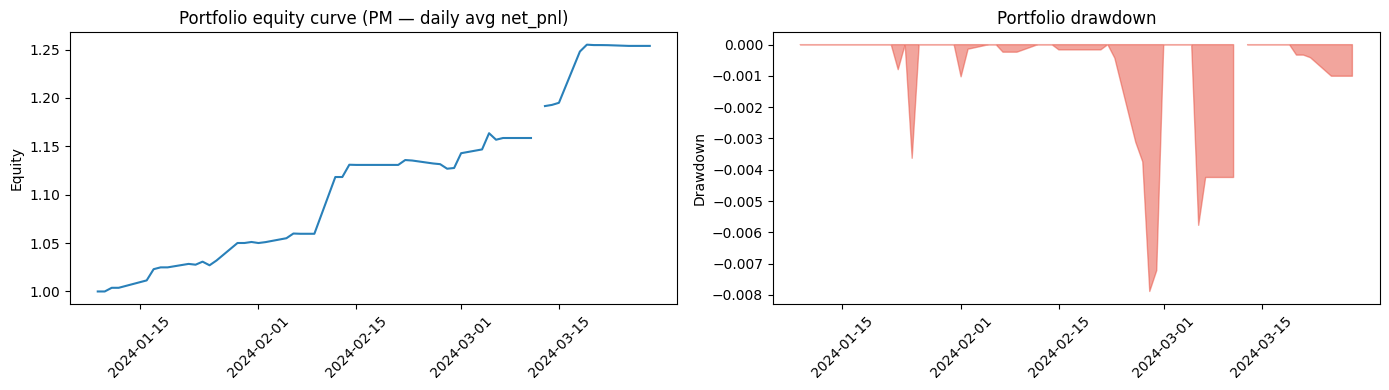

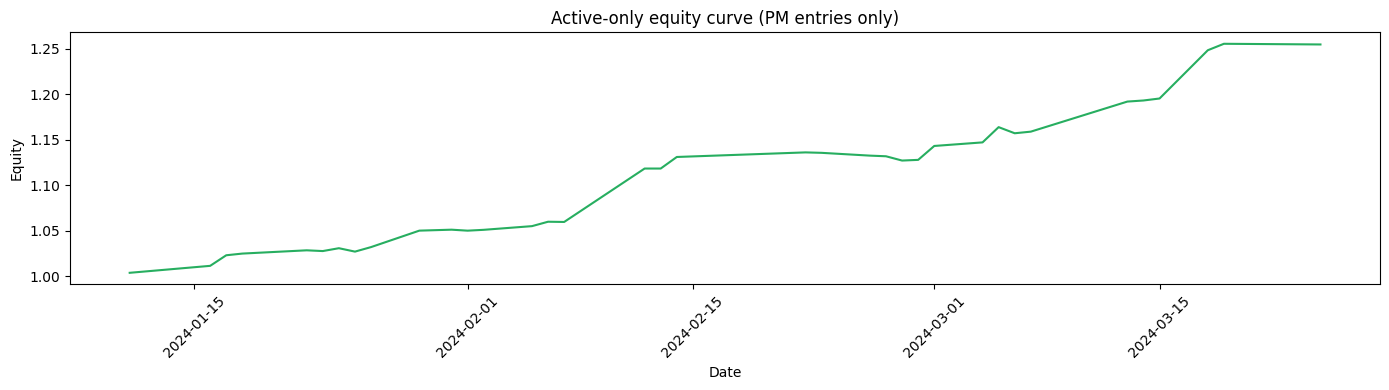

CLASSIFIER PROBABILITY DISTRIBUTIONS (selected candidates)
  P_short mean = 0.3015
  P_flat mean = 0.3855
  P_long mean = 0.3131


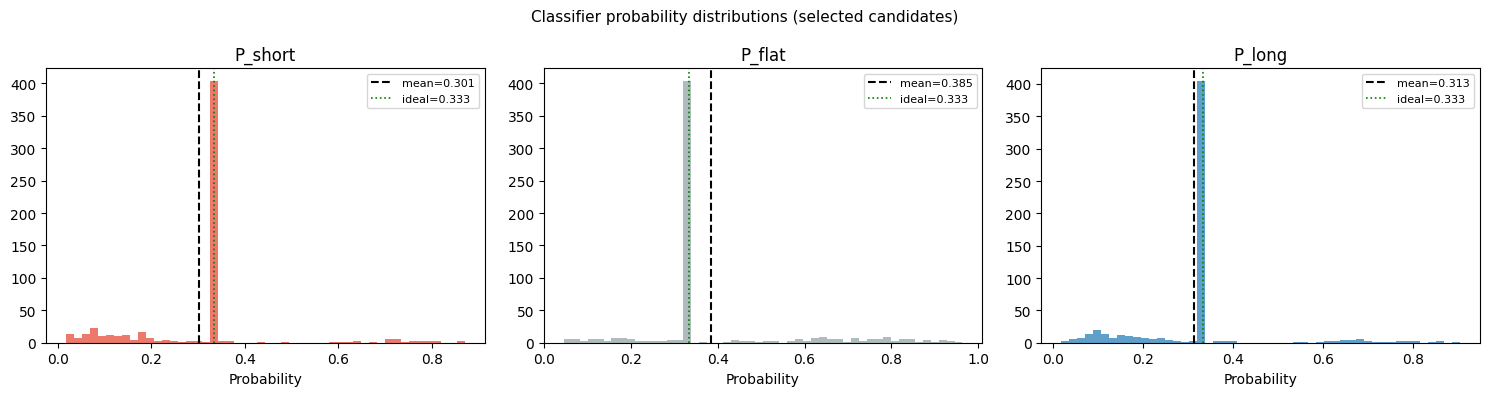

In [21]:
# Cell 13b — portfolio metrics deep-dive + classifier probability analysis

import math as _math

# ── PART 1: PM-based portfolio metrics ───────────────────────────────────
print("=" * 60)
print("PORTFOLIO METRICS  (PositionManager — daily avg across sectors)")
print("=" * 60)
print("10 sectors trade simultaneously. Daily return = mean net_pnl across sectors.")
print()
display(metrics.to_frame("value").round(4))

# Equity curve from PM daily net_pnl
daily_ret_pm = trades.groupby("date")["net_pnl"].mean().sort_index()
eq_pm = (1.0 + daily_ret_pm).cumprod()
dd_pm = eq_pm / eq_pm.cummax() - 1.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(eq_pm.index, eq_pm.values, color="#2980b9", lw=1.5)
axes[0].set_title("Portfolio equity curve (PM — daily avg net_pnl)")
axes[0].set_ylabel("Equity"); axes[0].tick_params(axis="x", rotation=45)
axes[1].fill_between(dd_pm.index, dd_pm.values, 0, color="#e74c3c", alpha=0.5)
axes[1].set_title("Portfolio drawdown")
axes[1].set_ylabel("Drawdown"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# Active-only equity (days when at least one sector has position != 0)
active_days_set = set(trades[trades["position"] != 0]["date"].unique())
daily_ret_active = daily_ret_pm[daily_ret_pm.index.isin(active_days_set)]
if not daily_ret_active.empty:
    eq_active = (1.0 + daily_ret_active).cumprod()
    plt.figure(figsize=(14, 4))
    plt.plot(eq_active.index, eq_active.values, color="#27ae60", lw=1.5)
    plt.title("Active-only equity curve (PM entries only)")
    plt.xlabel("Date"); plt.ylabel("Equity")
    plt.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

# ── PART 2: Classifier probability distributions ─────────────────────────
print("=" * 60)
print("CLASSIFIER PROBABILITY DISTRIBUTIONS (selected candidates)")
print("=" * 60)
sp = selected_panel.copy()
for col in ["P_short", "P_flat", "P_long"]:
    if col in sp.columns:
        print(f"  {col} mean = {sp[col].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["P_short", "P_flat", "P_long"],
                           ["#e74c3c", "#95a5a6", "#2980b9"]):
    if col in sp.columns:
        ax.hist(sp[col].dropna(), bins=50, color=color, alpha=0.75)
        ax.axvline(sp[col].mean(), color="black", lw=1.5, ls="--",
                   label=f"mean={sp[col].mean():.3f}")
        ax.axvline(0.333, color="green", lw=1.2, ls=":", label="ideal=0.333")
        ax.set_title(col); ax.set_xlabel("Probability"); ax.legend(fontsize=8)
plt.suptitle("Classifier probability distributions (selected candidates)", fontsize=11)
plt.tight_layout(); plt.show()


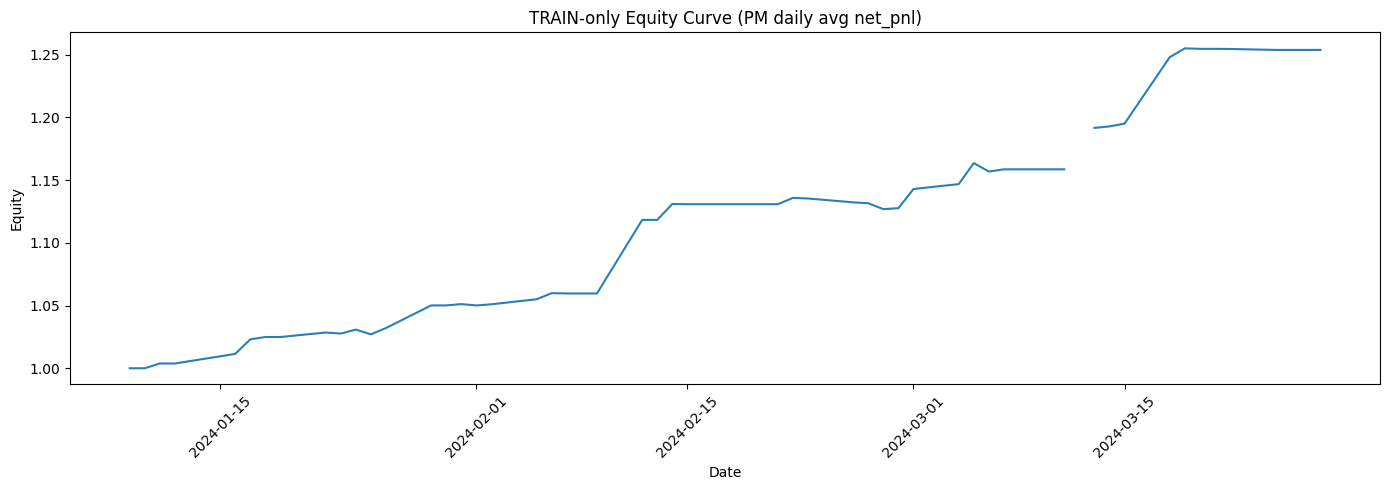

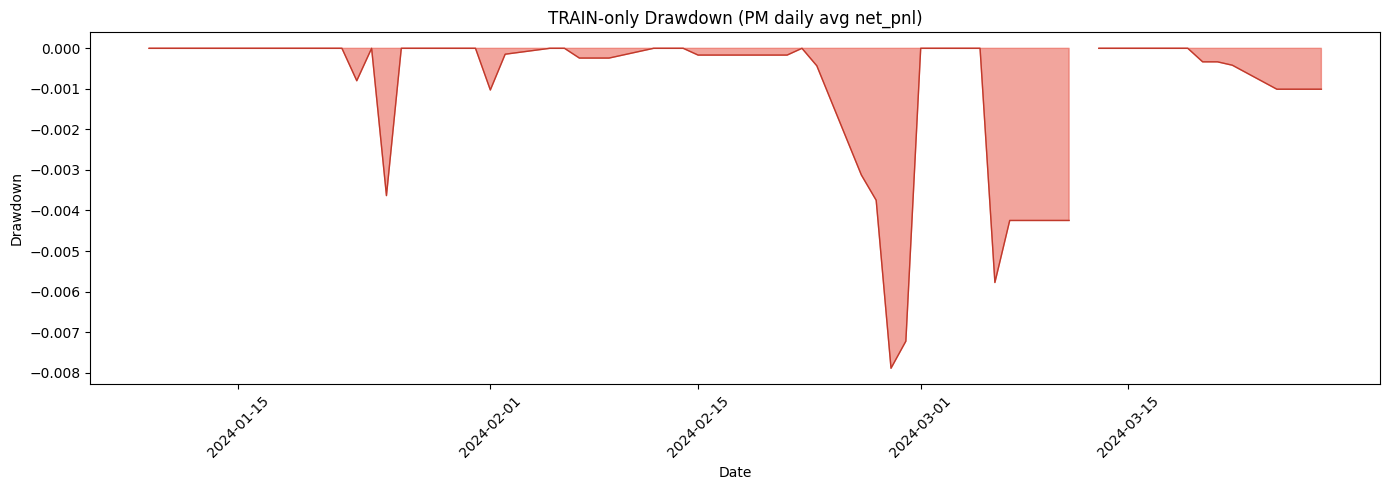

Active days (position != 0): 50
Total days in eval: 58
Final equity: 1.2538  (25.38%)


In [22]:
# Cell 14 — equity curve and drawdown (PM output)
active = trades[trades["position"] != 0].copy()
daily_ret = trades.groupby("date")["net_pnl"].mean().sort_index()
equity    = (1.0 + daily_ret).cumprod()
drawdown  = equity / equity.cummax() - 1.0

plt.figure(figsize=(14, 5))
plt.plot(equity.index, equity.values, color="#2980b9", lw=1.5)
plt.title("TRAIN-only Equity Curve (PM daily avg net_pnl)")
plt.xlabel("Date"); plt.ylabel("Equity")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 5))
plt.fill_between(drawdown.index, drawdown.values, 0, color="#e74c3c", alpha=0.5)
plt.plot(drawdown.index, drawdown.values, color="#c0392b", lw=1)
plt.title("TRAIN-only Drawdown (PM daily avg net_pnl)")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"Active days (position != 0): {len(active)}")
print(f"Total days in eval: {len(daily_ret)}")
print(f"Final equity: {equity.iloc[-1]:.4f}  ({(equity.iloc[-1]-1)*100:.2f}%)")


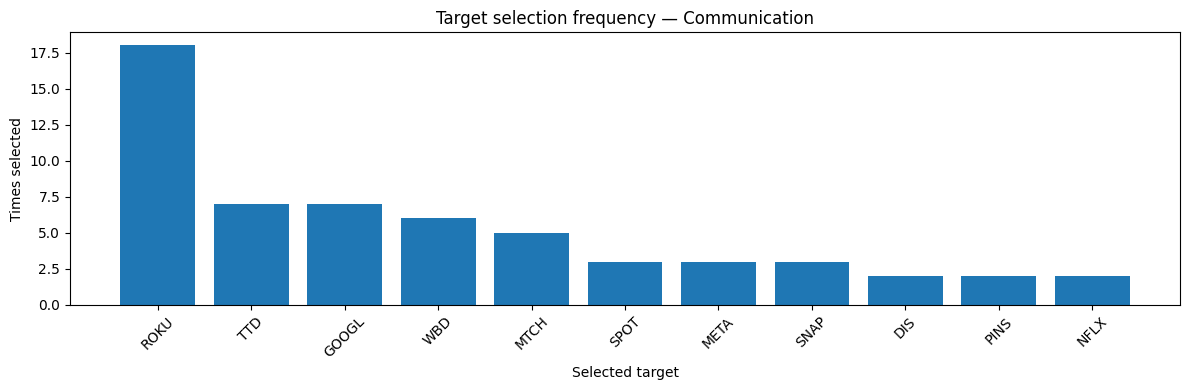

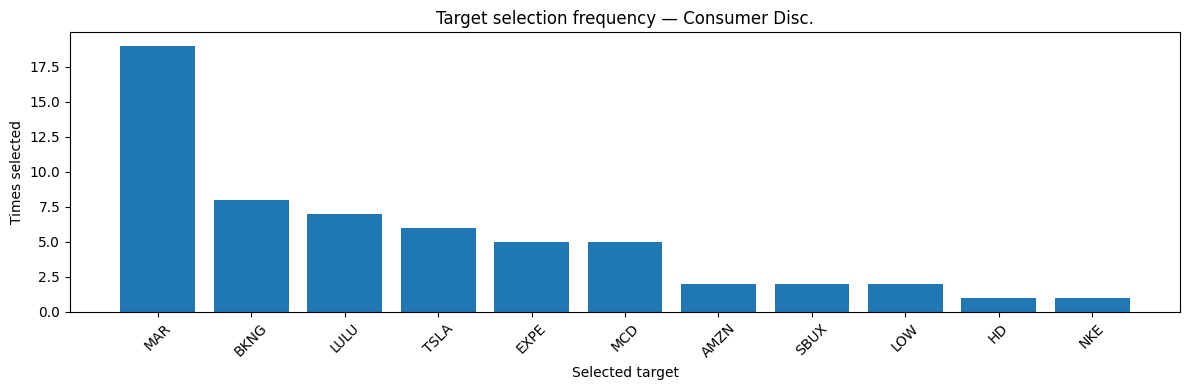

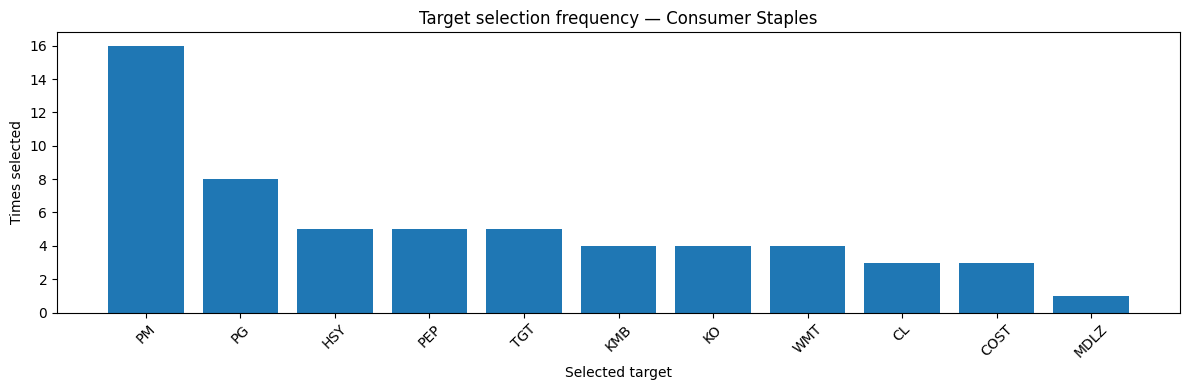

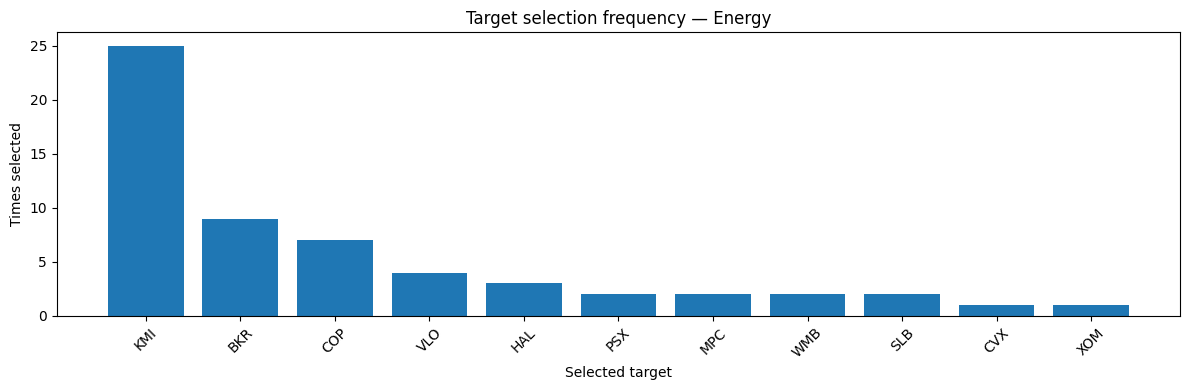

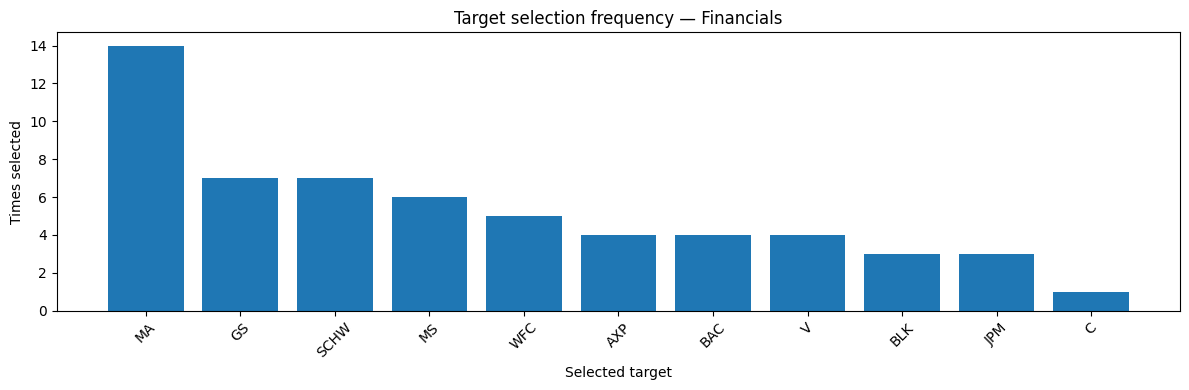

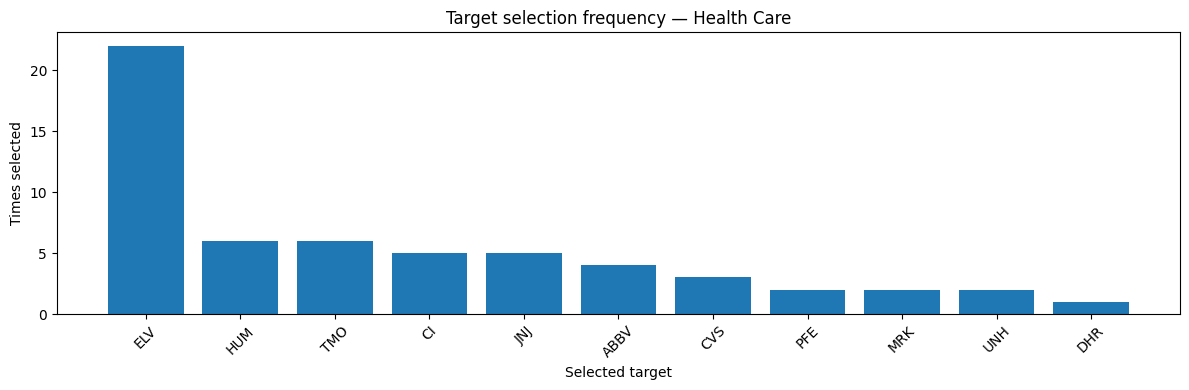

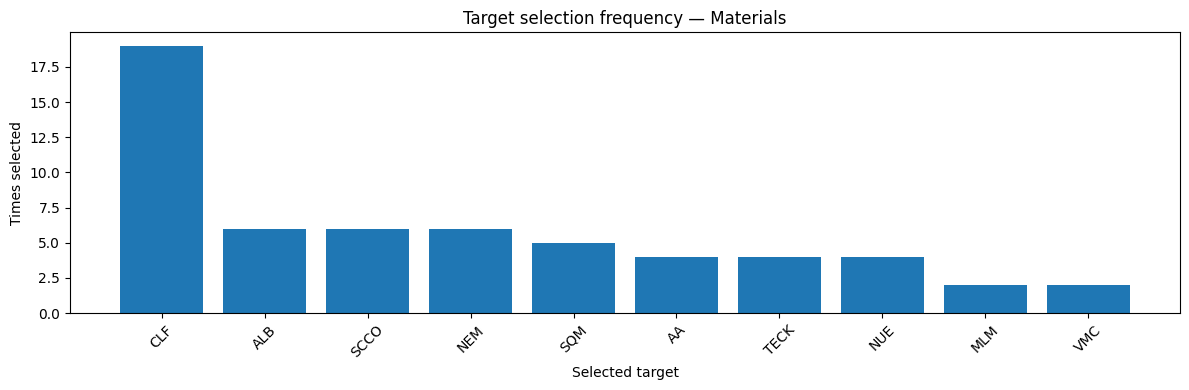

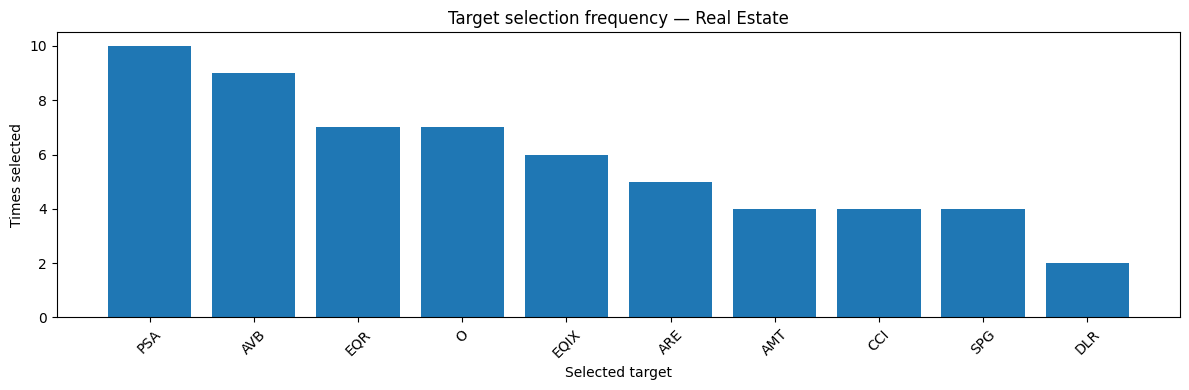

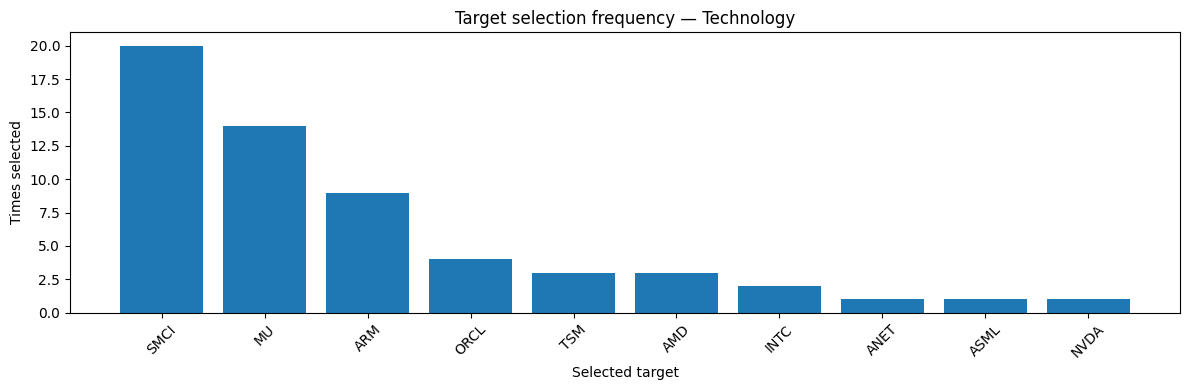

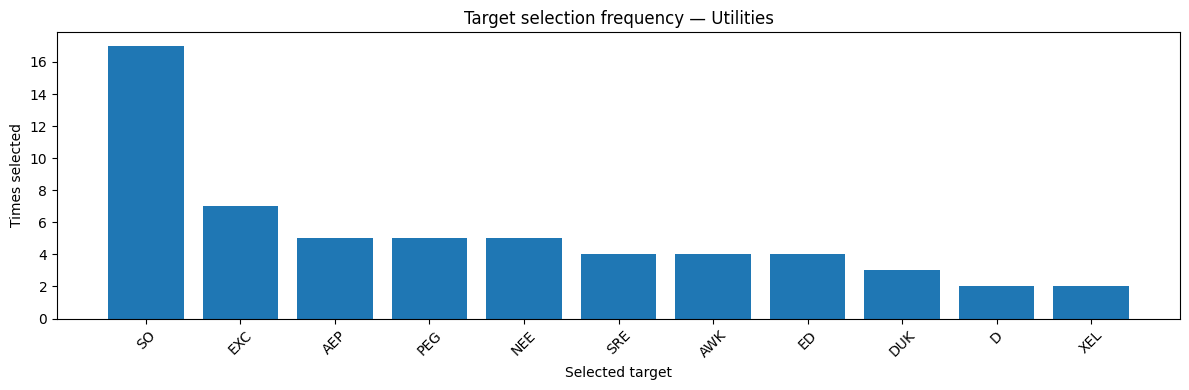

In [23]:
# Cell 15 — plots: target selection frequency
if not selection_summary.empty:
    for sector, sub in selection_summary.groupby("sector"):
        sub = sub.sort_values("times_selected", ascending=False)
        plt.figure(figsize=(12, 4))
        plt.bar(sub["selected_target"], sub["times_selected"])
        plt.title(f"Target selection frequency — {sector}")
        plt.xlabel("Selected target")
        plt.ylabel("Times selected")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


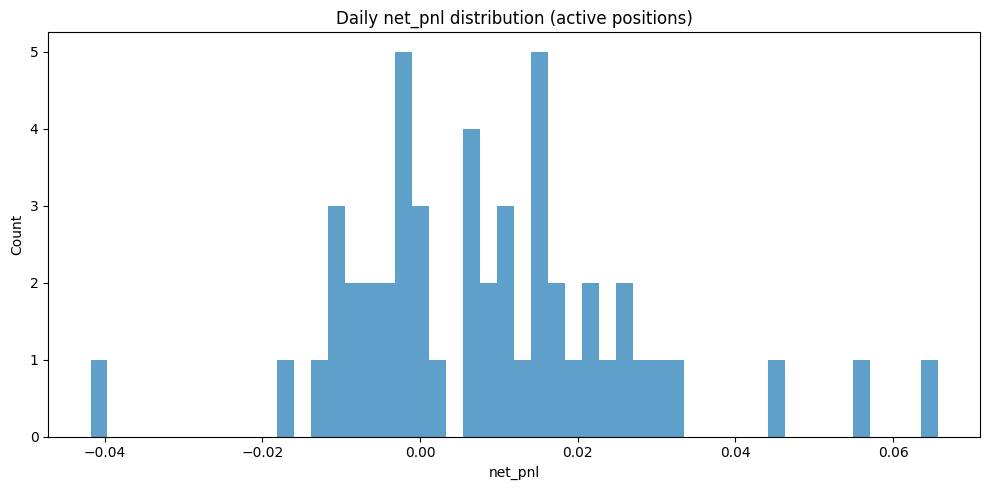

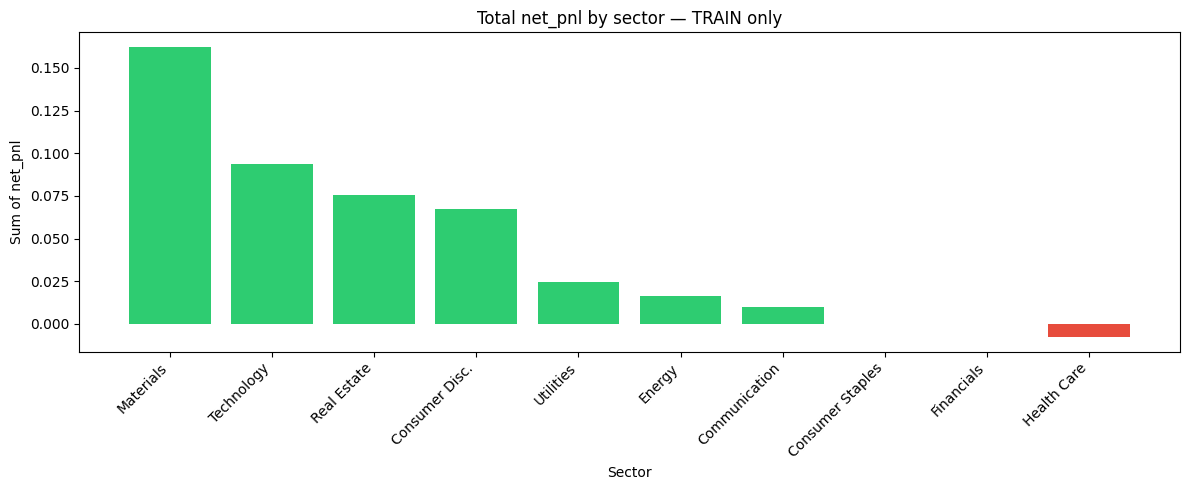

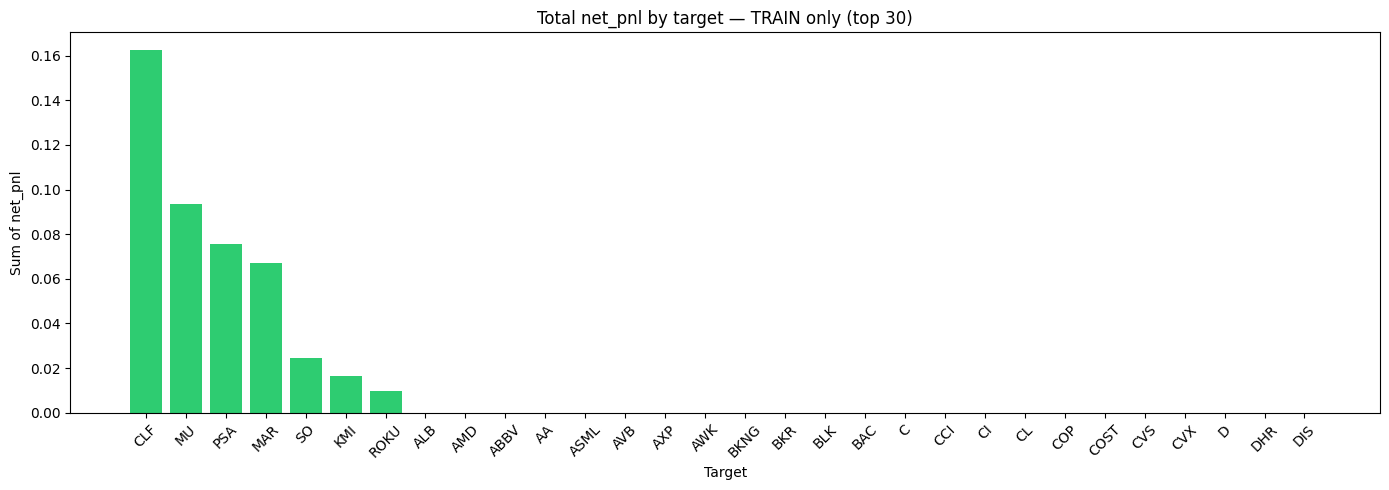

In [24]:
# Cell 16 — PnL by sector and by target

# Daily net_pnl per sector (active days only)
if not active.empty:
    plt.figure(figsize=(10, 5))
    plt.hist(active["net_pnl"].dropna(), bins=50, color="#2980b9", alpha=0.75)
    plt.title("Daily net_pnl distribution (active positions)")
    plt.xlabel("net_pnl"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

pnl_sector = trades.groupby("sector")["net_pnl"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
plt.bar(pnl_sector.index, pnl_sector.values, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in pnl_sector.values])
plt.title("Total net_pnl by sector — TRAIN only")
plt.xlabel("Sector"); plt.ylabel("Sum of net_pnl")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

pnl_target = trades.groupby("target")["net_pnl"].sum().sort_values(ascending=False).head(30)
plt.figure(figsize=(14, 5))
plt.bar(pnl_target.index, pnl_target.values, color=["#2ecc71" if v >= 0 else "#e74c3c" for v in pnl_target.values])
plt.title("Total net_pnl by target — TRAIN only (top 30)")
plt.xlabel("Target"); plt.ylabel("Sum of net_pnl")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


,sector,selected_target,times_selected,alpha_final,beta_final,bandit_score_final
6,Communication,ROKU,18,2,1,0.666667
0,Communication,DIS,2,1,1,0.500000
1,Communication,GOOGL,7,1,1,0.500000
2,Communication,META,3,1,1,0.500000
3,Communication,MTCH,5,1,1,0.500000
...,...,...,...,...,...,...
101,Utilities,EXC,7,1,1,0.500000
102,Utilities,NEE,5,1,1,0.500000
103,Utilities,PEG,5,1,1,0.500000
105,Utilities,SRE,4,1,1,0.500000


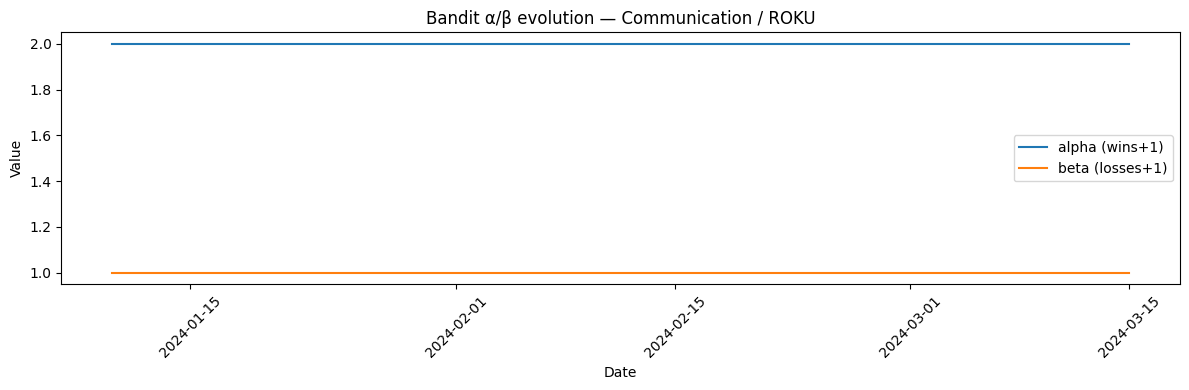

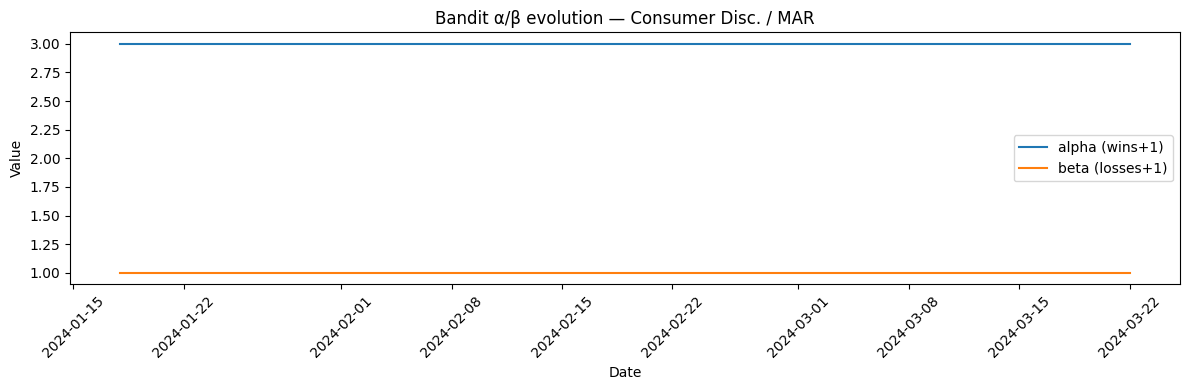

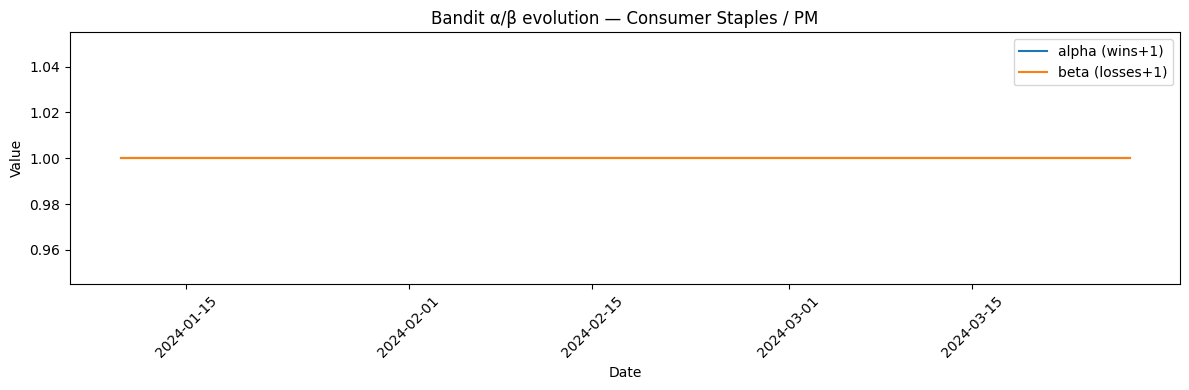

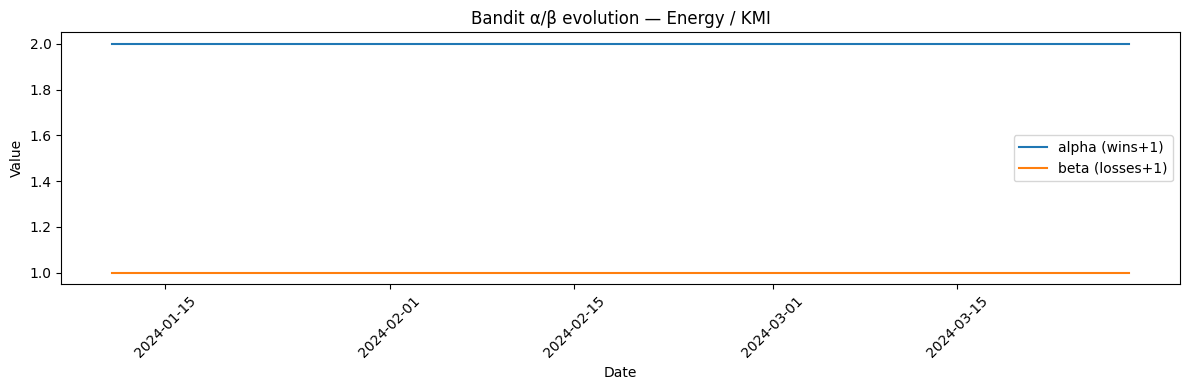

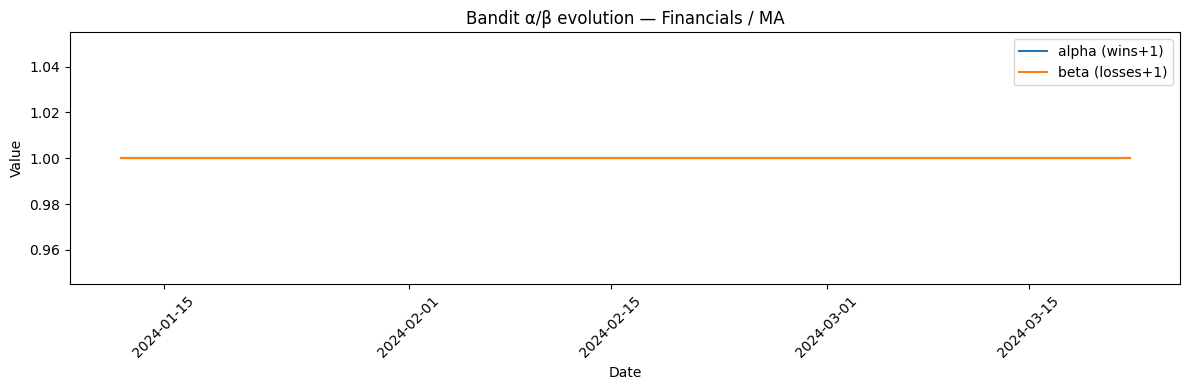

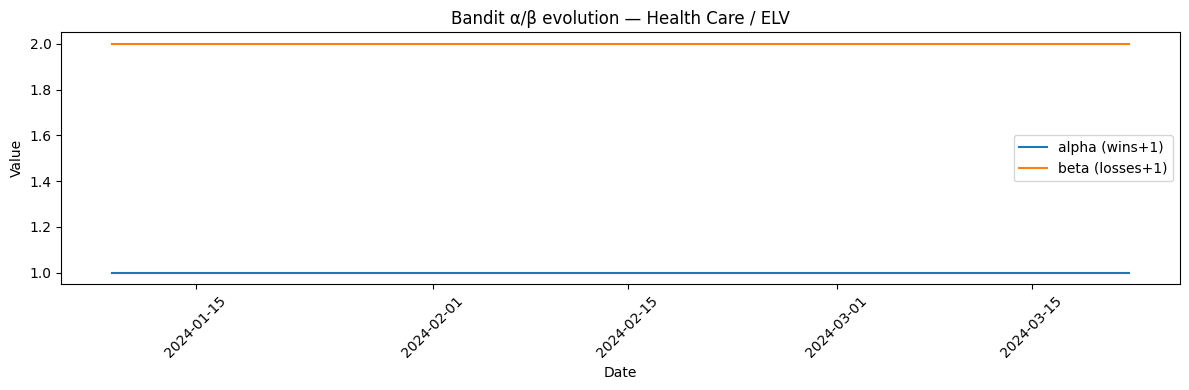

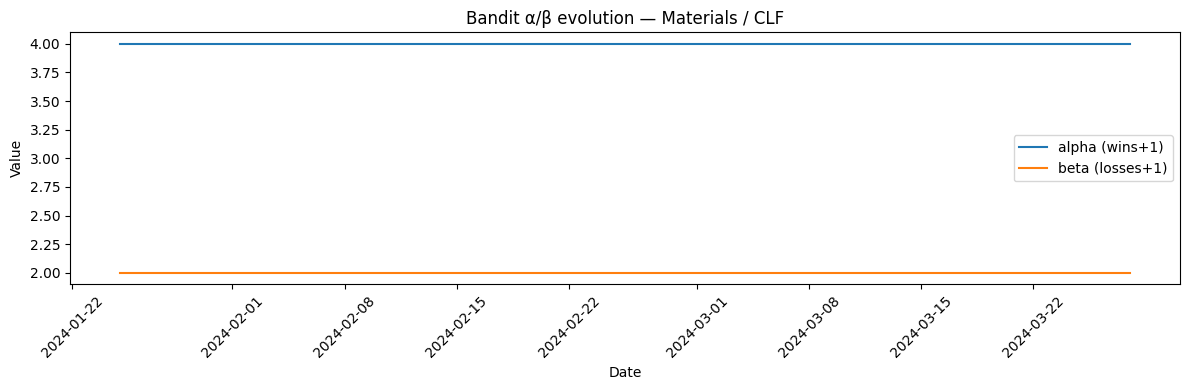

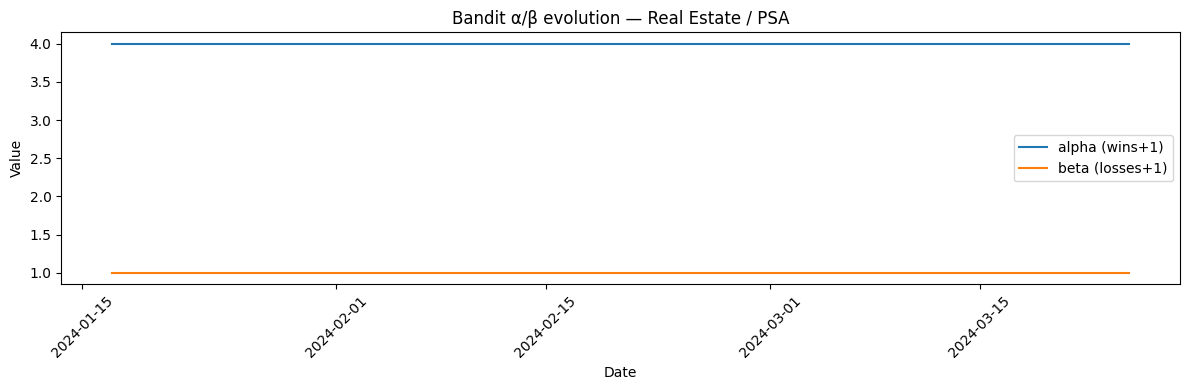

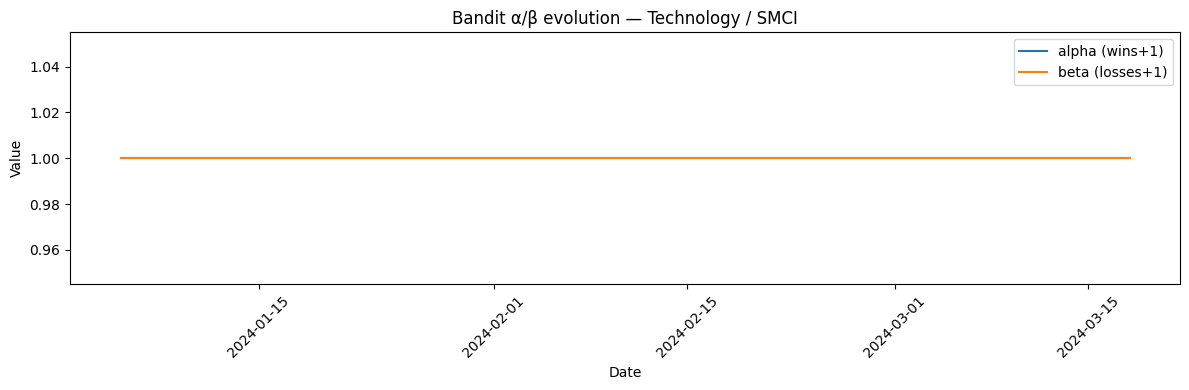

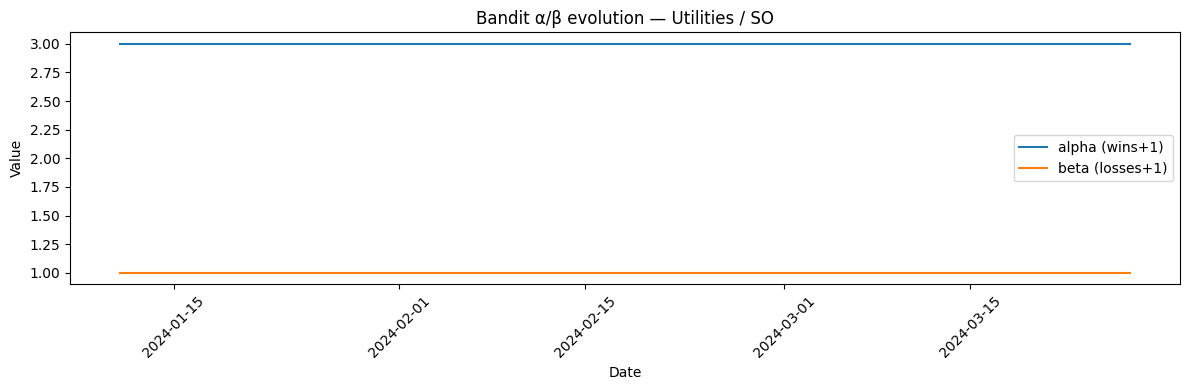

In [25]:
# Cell 17 — bandit diagnostics
if not bandit_states.empty:
    # Summary: alpha/beta progression per sector/target
    bandit_overview = (
        bandit_states.groupby(["sector", "selected_target"])
        .agg(
            times_selected=("selected_target", "size"),
            alpha_final=("alpha_after", "last"),
            beta_final=("beta_after", "last"),
        )
        .reset_index()
    )
    bandit_overview["bandit_score_final"] = (
        bandit_overview["alpha_final"] / (bandit_overview["alpha_final"] + bandit_overview["beta_final"])
    )
    display(bandit_overview.sort_values(["sector", "bandit_score_final"], ascending=[True, False]))

    # Plot alpha/beta evolution for most-selected target in each sector
    for sector, sub in bandit_states.groupby("sector"):
        top_target = sub["selected_target"].value_counts().idxmax()
        ss = sub[sub["selected_target"] == top_target].sort_values("date")
        if len(ss) < 3:
            continue
        plt.figure(figsize=(12, 4))
        plt.plot(ss["date"], ss["alpha_after"], label="alpha (wins+1)")
        plt.plot(ss["date"], ss["beta_after"],  label="beta (losses+1)")
        plt.title(f"Bandit α/β evolution — {sector} / {top_target}")
        plt.xlabel("Date"); plt.ylabel("Value")
        plt.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [26]:
# Cell 18 — sanity checks
sanity = []

sanity.append(("TRAIN_ONLY_MODE active",
               "PASS" if TRAIN_ONLY_MODE else "FAIL"))

sanity.append(("Train tail horizon removed",
               "PASS" if len(train_fit_idx) < len(train_idx) else "FAIL"))

sanity.append(("selected_panel has rows",
               "PASS" if len(selected_panel) > 0 else "FAIL"))

sanity.append(("trades DataFrame has rows",
               "PASS" if len(trades) > 0 else "FAIL"))

# Check selected target is never in its own predictors_used
if "predictors_used" in selected_panel.columns:
    bad = selected_panel.apply(
        lambda r: str(r["target"]) in str(r.get("predictors_used", "")).split(","), axis=1
    ).sum()
    sanity.append(("Selected target excluded from predictors",
                   "PASS" if bad == 0 else f"FAIL ({bad} rows)"))

# NaN check on critical signal columns
nan_rows = int(selected_panel[["P_short", "P_flat", "P_long", "signal"]].isna().any(axis=1).sum())
sanity.append(("No NaN in classifier outputs",
               "PASS" if nan_rows == 0 else f"WARN ({nan_rows} rows)"))

# PM position sanity: position ∈ {-1, 0, 1}
if "position" in trades.columns:
    invalid_pos = int((~trades["position"].isin([-1, 0, 1])).sum())
    sanity.append(("PM positions in {-1,0,1}",
                   "PASS" if invalid_pos == 0 else f"FAIL ({invalid_pos})"))

# net_pnl is finite when position != 0
if "net_pnl" in trades.columns and "position" in trades.columns:
    active_pnl = trades[trades["position"] != 0]["net_pnl"]
    inf_pnl    = int((~np.isfinite(active_pnl.fillna(np.nan))).sum())
    sanity.append(("net_pnl finite when in position",
                   "PASS" if inf_pnl == 0 else f"WARN ({inf_pnl})"))

sanity_df = pd.DataFrame(sanity, columns=["check", "status"])
display(sanity_df)
all_pass = all(s == "PASS" for s in sanity_df["status"])
print("\nAll sanity checks PASS!" if all_pass else "\n⚠ Some checks failed — review above.")


,check,status
0,TRAIN_ONLY_MODE active,PASS
1,Train tail horizon removed,PASS
2,selected_panel has rows,PASS
3,trades DataFrame has rows,PASS
4,Selected target excluded from predictors,PASS
5,No NaN in classifier outputs,PASS
6,"PM positions in {-1,0,1}",PASS
7,net_pnl finite when in position,PASS



All sanity checks PASS!


In [27]:
# Cell 19 — save TRAIN-only outputs
out_dir = PROJECT_ROOT / "outputs"
out_dir.mkdir(exist_ok=True)

# Main outputs
trades.to_csv(out_dir / "dbts_train_trade_log.csv", index=False)
daily_scores.to_csv(out_dir / "dbts_train_daily_target_scores.csv", index=False)
sector_summary.to_csv(out_dir / "dbts_train_sector_summary.csv", index=False)
selection_summary.to_csv(out_dir / "dbts_train_target_selection_summary.csv", index=False)
cm_df.to_csv(out_dir / "dbts_train_confusion_matrix.csv", index=True)
metrics.to_frame("value").to_csv(out_dir / "dbts_train_metrics.csv")
sanity_df.to_csv(out_dir / "dbts_train_sanity_checks.csv", index=False)
selected_panel.to_csv(out_dir / "dbts_train_selected_panel.csv", index=False)

if not completed_trades.empty:
    completed_trades.to_csv(out_dir / "dbts_train_completed_trades.csv", index=False)

if "predictor_summary" in dir() and not predictor_summary.empty:
    predictor_summary.to_csv(out_dir / "dbts_train_predictor_summary.csv", index=False)

saved = [
    "dbts_train_trade_log.csv", "dbts_train_daily_target_scores.csv",
    "dbts_train_sector_summary.csv", "dbts_train_target_selection_summary.csv",
    "dbts_train_confusion_matrix.csv", "dbts_train_metrics.csv",
    "dbts_train_sanity_checks.csv", "dbts_train_selected_panel.csv",
    "dbts_train_completed_trades.csv",
]
print("Saved TRAIN-only DBTS outputs:")
for name in saved:
    p = out_dir / name
    if p.exists():
        print(f"  ✓ {p}")


Saved TRAIN-only DBTS outputs:
  ✓ c:\algo-trading-project\outputs\dbts_train_trade_log.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_daily_target_scores.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_sector_summary.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_target_selection_summary.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_confusion_matrix.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_metrics.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_sanity_checks.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_selected_panel.csv
  ✓ c:\algo-trading-project\outputs\dbts_train_completed_trades.csv


In [28]:
# Cell 20 — conclusion
n_entries   = int(metrics.get("total_entries", 0))
n_long      = int(metrics.get("long_entries", 0))
n_short     = int(metrics.get("short_entries", 0))
sharpe      = metrics.get("sharpe", np.nan)
cum_ret     = metrics.get("cumulative_return", np.nan)
win_rate    = metrics.get("win_rate_days", np.nan)
max_dd      = metrics.get("max_drawdown", np.nan)
active_days = int(metrics.get("active_days", 0))

print("=" * 60)
print("TRAIN-ONLY DIAGNOSTIC SUMMARY")
print("=" * 60)
print(f"  PositionManager entries:  {n_entries:,}  (long {n_long}, short {n_short})")
print(f"  Active-position rows:     {active_days:,}")
print(f"  Completed trades:         {len(completed_trades) if not completed_trades.empty else 0}")
print(f"  Unique selected targets:  {int(selected_panel['target'].nunique())}")
print(f"  Target switches total:    {int(target_switch_summary['target_switches'].sum()) if not target_switch_summary.empty else 0}")
print()
print(f"  Sharpe:             {sharpe:.4f}" if np.isfinite(sharpe) else "  Sharpe:             n/a")
print(f"  Cumulative return:  {cum_ret*100:.2f}%" if np.isfinite(cum_ret) else "  Cumulative return:  n/a")
print(f"  Win rate (days):    {win_rate*100:.1f}%" if np.isfinite(win_rate) else "  Win rate:           n/a")
print(f"  Max drawdown:       {max_dd*100:.2f}%" if np.isfinite(max_dd) else "  Max drawdown:       n/a")
print()
print("Reminder: this is IN-SAMPLE TRAIN ONLY.")
print("Goal: verify the mechanism is alive (can the system earn on data it memorized?).")
print("True OOS evaluation requires running on the held-out test set.")


TRAIN-ONLY DIAGNOSTIC SUMMARY
  PositionManager entries:  17  (long 7, short 10)
  Active-position rows:     50
  Completed trades:         17
  Unique selected targets:  107
  Target switches total:    455

  Sharpe:             9.8674
  Cumulative return:  25.38%
  Win rate (days):    43.1%
  Max drawdown:       -0.79%

Reminder: this is IN-SAMPLE TRAIN ONLY.
Goal: verify the mechanism is alive (can the system earn on data it memorized?).
True OOS evaluation requires running on the held-out test set.
